In [1]:
# [Cell 1] — Notebook overview, imports, device setup, and global config
# -----------------------------------------------------------------------------
# PURPOSE
# This notebook implements an agent-first scientific workflow for physics-aware
# neural modeling. The language model does not solve physics directly. Instead,
# it proposes schema-valid experimental actions (hypotheses, priors, audits),
# while physics-aware expert models perform the actual numerical modeling.
#
# HIGH-LEVEL SYSTEM
# -----------------
#   Research State
#      -> Evidence Summary
#      -> Belief / Uncertainty Update
#      -> Planner (schema-constrained)
#      -> Hypothesis Routing / Prior Injection
#      -> Expert Tournament
#      -> Critic / Acceptance Gate
#      -> Memory / Reporting
#
# This notebook is designed as a clean v1 agent notebook that keeps the
# scientific roles separated and transparent.
# -----------------------------------------------------------------------------

import os
import re
import json
import math
import time
import random
import warnings
import hashlib

from copy import deepcopy
from pathlib import Path
from dataclasses import dataclass, asdict, field
from datetime import datetime
from typing import Any, Dict, List, Tuple, Optional, Mapping

import numpy as np
import torch
import torch.nn as nn
import torch.autograd as autograd
import requests

import matplotlib.pyplot as plt
from IPython.display import display, Markdown, clear_output

warnings.filterwarnings("ignore")

# -----------------------------------------------------------------------------
# Device and reproducibility
# -----------------------------------------------------------------------------
DEVICE = torch.device(
    "cuda" if torch.cuda.is_available()
    else "mps" if getattr(torch.backends, "mps", None) and torch.backends.mps.is_available()
    else "cpu"
)

SEED = 1337
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

print(f"[BOOT] device={DEVICE}, seed={SEED}")

# -----------------------------------------------------------------------------
# Global training / orchestration config
# -----------------------------------------------------------------------------
EPOCHS_FAST = 800
EPOCHS_FULL = 4000

FNO_STEPS_FAST = 200
FNO_STEPS_FULL = 1200

PRINT_EVERY = 100
LIVE_PLOT_EVERY = 50

DEFAULT_BUDGET = "full"   # "fast" or "full"
AUDIT_STEPS = 40

# Notebook / plotting toggles
ENABLE_LIVE_PLOTS = True
PLOT_FIGSIZE = (8, 4)

# -----------------------------------------------------------------------------
# Output directories
# -----------------------------------------------------------------------------
RUN_DIR = "runs"
PLOTS_DIR = os.path.join(RUN_DIR, "plots")
LOG_DIR = os.path.join(RUN_DIR, "logs")

Path(RUN_DIR).mkdir(parents=True, exist_ok=True)
Path(PLOTS_DIR).mkdir(parents=True, exist_ok=True)
Path(LOG_DIR).mkdir(parents=True, exist_ok=True)

[BOOT] device=cuda, seed=1337


In [2]:
# [Cell 2] — Serialization, logging, plotting, and notebook display helpers
# -----------------------------------------------------------------------------
# PURPOSE
# This cell contains:
#   - safe JSON conversion
#   - JSONL append helpers
#   - Markdown display helpers
#   - live plotting helpers for training and orchestration
# -----------------------------------------------------------------------------

def _as_int(x: Any) -> int:
    if isinstance(x, tuple):
        return int(x[0])
    return int(x)


def _safe_float(x: Any, default: float = float("nan")) -> float:
    try:
        return float(x)
    except Exception:
        return default


def _json_safe(x: Any) -> Any:
    try:
        import numpy as _np
    except Exception:
        _np = None

    if isinstance(x, torch.Tensor):
        if x.numel() == 1:
            return float(x.detach().cpu().item())
        return x.detach().cpu().tolist()

    if _np is not None and isinstance(x, (_np.number,)):
        return float(x)

    if isinstance(x, (float, int, str, bool)) or x is None:
        return x

    if isinstance(x, dict):
        return {k: _json_safe(v) for k, v in x.items()}

    if isinstance(x, (list, tuple)):
        return [_json_safe(v) for v in x]

    try:
        return json.loads(json.dumps(x))
    except Exception:
        return str(x)


def _fmt_num(v: Any, fmt: str = ".2e", na: str = "n/a") -> str:
    try:
        if v is None:
            return na
        vf = float(v)
        if math.isnan(vf) or math.isinf(vf):
            return na
        return format(vf, fmt)
    except Exception:
        return na


def append_jsonl(path: str, rec: dict) -> None:
    with open(path, "a", encoding="utf-8") as f:
        f.write(json.dumps(_json_safe(rec), default=float) + "\n")


def show_markdown_report(title: str, report: Optional[str]) -> None:
    print("=" * 100)
    print(title)
    print("=" * 100)
    if not report:
        print("No report generated.")
        return
    try:
        display(Markdown(report))
    except Exception:
        print(report)


# -----------------------------------------------------------------------------
# Live plotting helpers
# -----------------------------------------------------------------------------
def maybe_live_plot_training(history: Dict[str, List[float]], title: str, keys: Optional[List[str]] = None):
    """
    Live-update a single training figure inside the notebook.
    """
    if not ENABLE_LIVE_PLOTS:
        return

    if keys is None:
        keys = list(history.keys())

    clear_output(wait=True)
    fig, ax = plt.subplots(figsize=PLOT_FIGSIZE)

    for k in keys:
        vals = history.get(k, [])
        if len(vals) > 0:
            ax.plot(vals, label=k)

    ax.set_title(title)
    ax.set_xlabel("Logging step")
    ax.set_ylabel("Metric")
    ax.grid(True, alpha=0.3)
    ax.legend()
    plt.show()


def plot_agent_progress(state):
    """
    Plot a compact orchestration summary using accepted/rejected runs and the
    best metrics seen so far.
    """
    if not ENABLE_LIVE_PLOTS:
        return

    clear_output(wait=True)

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    # Left panel: action history
    if len(state.action_history) > 0:
        xs = np.arange(len(state.action_history))
        ys = np.arange(len(state.action_history))
        axes[0].plot(xs, ys)
        axes[0].set_xticks(xs)
        axes[0].set_xticklabels(state.action_history, rotation=45, ha="right")
        axes[0].set_title(f"{state.domain} action history")
        axes[0].set_ylabel("Step index")
        axes[0].grid(True, alpha=0.3)
    else:
        axes[0].set_title(f"{state.domain} action history")
        axes[0].text(0.5, 0.5, "No actions yet", ha="center", va="center")

    # Right panel: latest best metrics
    metrics = state.best_metrics or {}
    metric_names = []
    metric_vals = []

    if state.domain == "PDE":
        for k in ["data_mse", "physics_residual", "physics_residual_fd", "rel_L2"]:
            v = metrics.get(k, None)
            if v is not None and math.isfinite(_safe_float(v)):
                metric_names.append(k)
                metric_vals.append(_safe_float(v))
    else:
        for k in ["vecfield_mse", "trajectory_mse_short", "invariant_drift_short", "invariant_drift"]:
            v = metrics.get(k, None)
            if v is not None and math.isfinite(_safe_float(v)):
                metric_names.append(k)
                metric_vals.append(_safe_float(v))

    if metric_names:
        axes[1].bar(range(len(metric_names)), metric_vals)
        axes[1].set_xticks(range(len(metric_names)))
        axes[1].set_xticklabels(metric_names, rotation=45, ha="right")
        axes[1].set_title(f"{state.domain} best metrics")
        axes[1].grid(True, axis="y", alpha=0.3)
    else:
        axes[1].set_title(f"{state.domain} best metrics")
        axes[1].text(0.5, 0.5, "No accepted metrics yet", ha="center", va="center")

    plt.tight_layout()
    plt.show()

In [3]:
# [Cell 3] — Physics utilities, synthetic data generation, and coarse numerics
# -----------------------------------------------------------------------------
# PURPOSE
# This cell provides:
#   - tensor conversion helpers
#   - finite differences
#   - stable linear solves
#   - synthetic Burgers-like PDE data
#   - synthetic pendulum ODE data
#   - heuristic summaries used later by the planner and belief layer
# -----------------------------------------------------------------------------

def to_torch(x: Any, *, dtype=torch.float32) -> torch.Tensor:
    return torch.tensor(x, dtype=dtype, device=DEVICE)


def finite_diff_1d(u: torch.Tensor, dx: torch.Tensor, order: int = 1) -> torch.Tensor:
    if order == 1:
        return (torch.roll(u, -1, dims=-1) - torch.roll(u, 1, dims=-1)) / (2 * dx)
    if order == 2:
        return (torch.roll(u, -1, dims=-1) - 2 * u + torch.roll(u, 1, dims=-1)) / (dx * dx)
    raise ValueError("Unsupported finite difference order")


def safe_solve(A: torch.Tensor, B: torch.Tensor) -> torch.Tensor:
    try:
        return torch.linalg.solve(A, B)
    except (NotImplementedError, RuntimeError):
        return torch.linalg.pinv(A) @ B


def linregress_Xy(X: torch.Tensor, y: torch.Tensor) -> torch.Tensor:
    XtX = X.T @ X
    Xty = X.T @ y
    return safe_solve(XtX, Xty)


def gen_burgers_1d(nx: int = 128, nt: int = 200, L: float = 2 * math.pi, T: float = 1.0, nu: float = 0.01):
    """
    Lightweight synthetic Burgers-like generator for notebook experimentation.
    """
    x = torch.linspace(0, L, nx, device=DEVICE)
    dx = x[1] - x[0]
    dt = T / nt

    u = torch.sin(x) + 0.25 * torch.sin(2 * x)
    U = [u.clone()]

    for _ in range(nt):
        ux = finite_diff_1d(u, dx, 1)
        uxx = finite_diff_1d(u, dx, 2)
        u = u - dt * (u * ux) + dt * nu * uxx
        U.append(u.clone())

    U = torch.stack(U, dim=0)
    t = torch.linspace(0, T, nt + 1, device=DEVICE)
    return x, t, U, nu


def gen_pendulum(n_traj: int = 32, steps: int = 300, dt: float = 0.02, g: float = 9.81, L: float = 1.0):
    """
    Lightweight synthetic pendulum generator in (q, p) coordinates.
    """
    qs, ps, dqs, dps = [], [], [], []

    for _ in range(n_traj):
        q = (torch.rand(1, device=DEVICE) - 0.5) * 1.0
        p = torch.zeros(1, device=DEVICE)

        tq, tp, tdq, tdp = [], [], [], []
        for _ in range(steps):
            dq = p
            dp = -(g / L) * torch.sin(q)

            tq.append(q.clone())
            tp.append(p.clone())
            tdq.append(dq.clone())
            tdp.append(dp.clone())

            q = q + dt * dq
            p = p + dt * dp

        qs.append(torch.stack(tq))
        ps.append(torch.stack(tp))
        dqs.append(torch.stack(tdq))
        dps.append(torch.stack(tdp))

    return torch.stack(qs), torch.stack(ps), torch.stack(dqs), torch.stack(dps), dt


@torch.no_grad()
def estimate_energy_flatness(q: torch.Tensor, dq: torch.Tensor) -> float:
    """
    A coarse heuristic for conservative structure.
    """
    E = (q.squeeze(-1) ** 2 + dq.squeeze(-1) ** 2).mean(dim=0).float()
    t = torch.arange(E.numel(), device=E.device, dtype=E.dtype).unsqueeze(1)
    beta = linregress_Xy(torch.cat([torch.ones_like(t), t], dim=1), E.unsqueeze(1))
    slope = beta[1].abs().item()
    return float(1.0 / (1.0 + slope))


@torch.no_grad()
def regress_ut_on_ux_uxx(U: torch.Tensor, x: torch.Tensor, t: torch.Tensor) -> Dict[str, Any]:
    """
    Coarse PDE character proxy:
    regress u_t against advection and diffusion-style terms.
    """
    dx = x[1] - x[0]
    dt = t[1] - t[0]

    ut = (U[1:] - U[:-1]) / dt
    mid = slice(1, -1)

    u = U[:-1][:, mid]
    ux = finite_diff_1d(u, dx, 1)
    uux = u * ux
    uxx = finite_diff_1d(u, dx, 2)

    X = torch.stack([uux.flatten(), uxx.flatten()], dim=1).float()
    y = ut[:, mid].flatten().unsqueeze(1).float()

    a, b = linregress_Xy(X, y).squeeze().tolist()
    return {"adv": abs(a), "diff": abs(b), "coef": (a, b)}

In [4]:
# [Cell 4] — Dataset builders, context packs, and quick data visuals
# -----------------------------------------------------------------------------
# PURPOSE
# This cell turns raw synthetic trajectories into:
#   - training-ready PDE / ODE datasets
#   - compact planner-facing context packs
#   - optional notebook visuals for sanity-checking generated data
#
# IMPORTANT
# The planner never sees raw tensors directly. It only sees structured summaries.
# -----------------------------------------------------------------------------

def _gen_pde_seed(
    nu_val: float = 0.01,
    noise_std: float = 0.0,
    nx: int = 96,
    nt: int = 160,
    T: float = 1.0,
    n_obs: int = 2048,
    n_col: int = 4096,
) -> Dict[str, Any]:
    x, t, U, nu = gen_burgers_1d(nx=nx, nt=nt, T=T, nu=nu_val)

    if noise_std > 0:
        U = U + noise_std * torch.randn_like(U)

    ti = torch.rand(n_obs, 1, device=DEVICE) * t[-1]
    xi = torch.rand(n_obs, 1, device=DEVICE) * x[-1]

    t_idx = (ti.squeeze(-1) * (t.shape[0] - 1) / float(t[-1])).clamp(0, t.shape[0] - 1).round().long()
    x_idx = (xi.squeeze(-1) * (x.shape[0] - 1) / float(x[-1])).clamp(0, x.shape[0] - 1).round().long()
    ui = U[t_idx, x_idx].unsqueeze(-1)

    t_col = torch.rand(n_col, 1, device=DEVICE) * t[-1]
    x_col = torch.rand(n_col, 1, device=DEVICE) * x[-1]

    t_slice_idx = int(0.75 * (t.shape[0] - 1))

    return {
        "x": x,
        "t": t,
        "U": U,
        "nu": nu,
        "ti": ti,
        "xi": xi,
        "ui": ui,
        "t_col": t_col,
        "x_col": x_col,
        "slice_t": 0.75,
        "x_eval": x,
        "Uref": U[t_slice_idx],
    }


def _gen_ode_seed(steps: int = 240, dt: float = 0.02, noise_std: float = 0.0, n_traj: int = 32) -> Dict[str, Any]:
    q, p, dq, dp, dt_sim = gen_pendulum(n_traj=n_traj, steps=steps, dt=dt)

    if noise_std > 0:
        q = q + noise_std * torch.randn_like(q)
        p = p + noise_std * torch.randn_like(p)

    return {
        "q": q,
        "p": p,
        "dq": dq,
        "dp": dp,
        "dt": dt_sim,
    }


def downsample_tensor(x: torch.Tensor, n: int) -> torch.Tensor:
    if x.numel() <= n:
        return x.detach().clone()
    idx = torch.linspace(0, x.shape[0] - 1, n, device=x.device).round().long()
    return x.index_select(0, idx)


@torch.no_grad()
def make_context_pack_pde(D: Dict[str, Any], *, n_time: int = 8, n_space: int = 64) -> Dict[str, Any]:
    x, t, U = D["x"], D["t"], D["U"]

    t_idx = torch.linspace(0, len(t) - 1, n_time, device=t.device).round().long()
    x_ds = downsample_tensor(x, n_space)

    U_slices = []
    for k in t_idx:
        idx = torch.linspace(0, len(x) - 1, len(x_ds), device=x.device).round().long()
        U_slices.append(U[k, idx].detach().cpu().tolist())

    hint = regress_ut_on_ux_uxx(U, x, t)

    return {
        "task": "pde_burgers_like",
        "x_span": [float(x.min()), float(x.max())],
        "t_span": [float(t.min()), float(t.max())],
        "nu_hint": None,
        "advection_proxy": float(hint["adv"]),
        "diffusion_proxy": float(hint["diff"]),
        "slices": {
            "t_grid": t[t_idx].detach().cpu().tolist(),
            "x_grid": x_ds.detach().cpu().tolist(),
            "U_at_ti": U_slices,
        },
    }


@torch.no_grad()
def make_context_pack_ode(D: Dict[str, Any], *, n_time: int = 128) -> Dict[str, Any]:
    q, p, dq, dp, dt = D["q"], D["p"], D["dq"], D["dp"], D["dt"]

    q1, p1 = q[0, :, 0], p[0, :, 0]
    ti = downsample_tensor(torch.arange(len(q1), device=q1.device) * dt, n_time)

    return {
        "task": "ode_pendulum_like",
        "dt": float(dt),
        "summary": {
            "q_mean": float(q1.mean()),
            "q_std": float(q1.std() + 1e-12),
            "p_mean": float(p1.mean()),
            "p_std": float(p1.std() + 1e-12),
        },
        "slices": {
            "t_grid": ti.detach().cpu().tolist(),
            "q": downsample_tensor(q1, n_time).detach().cpu().tolist(),
            "p": downsample_tensor(p1, n_time).detach().cpu().tolist(),
        },
    }


def preview_pde_data(D: Dict[str, Any]):
    if not ENABLE_LIVE_PLOTS:
        return
    x = D["x"].detach().cpu().numpy()
    t = D["t"].detach().cpu().numpy()
    U = D["U"].detach().cpu().numpy()

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].plot(x, U[0], label="t=0")
    axes[0].plot(x, U[len(t)//2], label="mid")
    axes[0].plot(x, U[-1], label="final")
    axes[0].set_title("PDE slices")
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    im = axes[1].imshow(U, aspect="auto", origin="lower")
    axes[1].set_title("PDE spatiotemporal field")
    plt.colorbar(im, ax=axes[1])
    plt.tight_layout()
    plt.show()


def preview_ode_data(D: Dict[str, Any]):
    if not ENABLE_LIVE_PLOTS:
        return
    q = D["q"][0, :, 0].detach().cpu().numpy()
    p = D["p"][0, :, 0].detach().cpu().numpy()
    dt = D["dt"]
    tt = np.arange(len(q)) * dt

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].plot(tt, q, label="q")
    axes[0].plot(tt, p, label="p")
    axes[0].set_title("ODE trajectory")
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    axes[1].plot(q, p)
    axes[1].set_title("Phase portrait")
    axes[1].grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

In [5]:
# [Cell 5] — Core neural expert architectures
# -----------------------------------------------------------------------------
# PURPOSE
# This cell defines the model families used by the agent:
#   - MLP backbone
#   - SA-PINN-style Burgers solver
#   - DeepHPMs
#   - FNO-lite
#   - HNN
#   - LNN
#
# These are the scientific computation components used by the agent.
# -----------------------------------------------------------------------------

class MLP(nn.Module):
    def __init__(self, in_dim: int, out_dim: int, hidden: int = 128, depth: int = 4, act=nn.Tanh):
        super().__init__()
        layers = [nn.Linear(in_dim, hidden), act()]
        for _ in range(depth - 1):
            layers += [nn.Linear(hidden, hidden), act()]
        layers += [nn.Linear(hidden, out_dim)]
        self.net = nn.Sequential(*layers)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.net(x)


def _sanitize_grads_(model: nn.Module) -> None:
    with torch.no_grad():
        for p in model.parameters():
            if p.grad is None:
                continue
            g = p.grad
            if torch.is_complex(g):
                g = g.real
            if not torch.isfinite(g).all():
                g = torch.nan_to_num(g, nan=0.0, posinf=0.0, neginf=0.0)
            p.grad = g


# -----------------------------------------------------------------------------
# SA-PINN-style Burgers expert
# -----------------------------------------------------------------------------
class SA_PINN_Burgers(nn.Module):
    def __init__(self, hidden: int = 128, depth: int = 4, nu: float = 0.01, nu_prior=None, nu_prior_w: float = 5e-3):
        super().__init__()
        self.nu = nn.Parameter(torch.tensor(float(nu), device=DEVICE))
        self.nu_prior = None if (nu_prior is None or not math.isfinite(nu_prior)) else float(nu_prior)
        self.nu_prior_w = float(nu_prior_w)
        self.fnn = MLP(2, 1, hidden, depth)
        self.mask = None

    def forward(self, t: torch.Tensor, x: torch.Tensor) -> torch.Tensor:
        return self.fnn(torch.cat([t, x], -1))

    def pde_residual(self, t: torch.Tensor, x: torch.Tensor) -> torch.Tensor:
        with torch.enable_grad():
            t = t.detach().to(DEVICE).requires_grad_(True)
            x = x.detach().to(DEVICE).requires_grad_(True)

            u = self.forward(t, x)
            ut = autograd.grad(u, t, torch.ones_like(u), create_graph=True, retain_graph=True)[0]
            ux = autograd.grad(u, x, torch.ones_like(u), create_graph=True, retain_graph=True)[0]
            uxx = autograd.grad(ux, x, torch.ones_like(ux), create_graph=True, retain_graph=True)[0]
            return ut + u * ux - self.nu * uxx

    def loss(self, t_data, x_data, u_data, t_col, x_col):
        pred = self.forward(t_data, x_data)
        mse_data = torch.mean((pred - u_data) ** 2)

        f = self.pde_residual(t_col, x_col)
        if (self.mask is None) or (self.mask.shape != f.shape):
            self.mask = nn.Parameter(torch.full_like(f.detach(), 0.0))

        # SA-PINN-style adaptive pointwise weighting
        w = torch.nn.functional.softplus(self.mask) + 1e-4
        mse_pde = torch.mean(w * (f ** 2))

        prior_pen = 0.0
        if self.nu_prior is not None:
            prior_pen = self.nu_prior_w * (self.nu - self.nu_prior) ** 2

        total = mse_data + mse_pde + prior_pen
        return total, mse_data.detach(), torch.mean(f.detach() ** 2)


# -----------------------------------------------------------------------------
# Deep Hidden Physics Model expert
# -----------------------------------------------------------------------------
class DeepHPMs(nn.Module):
    def __init__(self):
        super().__init__()
        self.net_u = MLP(2, 1, 128, 4)
        self.net_N = MLP(4, 1, 128, 4)

    def forward(self, t: torch.Tensor, x: torch.Tensor) -> torch.Tensor:
        return self.net_u(torch.cat([t, x], -1))

    def residual(self, t: torch.Tensor, x: torch.Tensor) -> torch.Tensor:
        t = t.detach().clone().requires_grad_(True)
        x = x.detach().clone().requires_grad_(True)

        u = self.forward(t, x)
        ut = autograd.grad(u, t, torch.ones_like(u), create_graph=True)[0]
        ux = autograd.grad(u, x, torch.ones_like(u), create_graph=True)[0]
        uxx = autograd.grad(ux, x, torch.ones_like(ux), create_graph=True)[0]

        N = self.net_N(torch.cat([u, ux, uxx, t], -1))
        return ut - N


# -----------------------------------------------------------------------------
# FNO-lite expert
# -----------------------------------------------------------------------------
class FNO1DLayer(nn.Module):
    def __init__(self, width: int, modes: int = 12):
        super().__init__()
        self.width = width
        self.modes = modes
        self.wr = nn.Parameter(torch.randn(width, width, modes) * 0.01)
        self.wi = nn.Parameter(torch.randn(width, width, modes) * 0.01)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        X = torch.fft.rfft(x, dim=-1)
        B, C, K = X.shape
        M = min(self.modes, K)
        if M == 0:
            return x

        W = torch.complex(self.wr[..., :M], self.wi[..., :M])
        out_fft = torch.zeros((B, C, K), dtype=X.dtype, device=X.device)
        out_fft[..., :M] = torch.einsum("bck,cdk->bdk", X[..., :M], W)
        return torch.fft.irfft(out_fft, n=x.shape[-1], dim=-1)


class FNO1D(nn.Module):
    def __init__(self, in_ch: int = 1, width: int = 64, layers: int = 4, modes: int = 12):
        super().__init__()
        self.proj_in = nn.Conv1d(in_ch, width, 1)
        self.blocks = nn.ModuleList([FNO1DLayer(width, modes) for _ in range(layers)])
        self.lins = nn.ModuleList([nn.Conv1d(width, width, 1) for _ in range(layers)])
        self.act = nn.GELU()
        self.proj_out = nn.Conv1d(width, 1, 1)

    def forward(self, u: torch.Tensor) -> torch.Tensor:
        x = self.proj_in(u)
        for f, w in zip(self.blocks, self.lins):
            x = self.act(f(x) + w(x))
        return self.proj_out(x)


# -----------------------------------------------------------------------------
# HNN and LNN experts
# -----------------------------------------------------------------------------
class HNN(nn.Module):
    def __init__(self, hidden: int = 128, depth: int = 4):
        super().__init__()
        self.H = MLP(2, 1, hidden, depth)

    def forward(self, q: torch.Tensor, p: torch.Tensor):
        qp = torch.cat([q, p], -1)
        H = self.H(qp)
        dH_dq, dH_dp = autograd.grad(H.sum(), (q, p), create_graph=True)
        dqdt = dH_dp
        dpdt = -dH_dq
        return dqdt, dpdt


class LNN(nn.Module):
    def __init__(self, hidden: int = 128, depth: int = 4):
        super().__init__()
        self.L = MLP(2, 1, hidden, depth)

    def accelerations(self, q: torch.Tensor, qdot: torch.Tensor) -> torch.Tensor:
        q = q.detach().clone().requires_grad_(True)
        qd = qdot.detach().clone().requires_grad_(True)

        L = self.L(torch.cat([q, qd], -1))
        dL_dq, dL_dqd = autograd.grad(L.sum(), (q, qd), create_graph=True)

        H = []
        for i in range(qd.shape[-1]):
            g = autograd.grad(dL_dqd[..., i].sum(), qd, retain_graph=True, create_graph=True)[0]
            H.append(g[..., None, :])

        M = torch.cat(H, -2)
        I = torch.eye(M.shape[-1], device=M.device, dtype=M.dtype).expand_as(M)
        M = M + 1e-2 * I

        rhs = dL_dq
        qdd = safe_solve(M, rhs.unsqueeze(-1)).squeeze(-1)
        return qdd

In [6]:
# [Cell 6] — Expert registry, builders, rollout helpers, training, scoring, and live training plots
# -----------------------------------------------------------------------------
# PURPOSE
# This cell implements:
#   - the unified expert interface,
#   - PDE fitters and scorers,
#   - ODE rollout-aware fitters and scorers,
#   - live notebook training plots.
#
# KEY DESIGN CHOICE
# -----------------
# ODE training is explicitly aligned with the scientific quantities the critic
# cares about:
#   - local vector-field fit
#   - short-horizon trajectory consistency
#   - short-horizon conservation behavior
# -----------------------------------------------------------------------------

@dataclass
class TrainCfg:
    lr: float = 1e-3
    epochs: int = 600
    batch_size: int = 2048
    print_every: int = PRINT_EVERY


class ExpertAdapter:
    def __init__(self, name, build_fn, fit_fn, score_fn):
        self.name = name
        self._build = build_fn
        self._fit = fit_fn
        self._score = score_fn
        self.model = None
        self.last_history = None

    def build(self, meta):
        self.model = self._build(meta)

    def fit(self, Dtrain, budget):
        out = self._fit(self.model, Dtrain, budget)
        if isinstance(out, tuple):
            self.model, self.last_history = out
            return self.model
        return out

    def score(self, Dval):
        return self._score(self.model, Dval)


# -----------------------------------------------------------------------------
# Builders
# -----------------------------------------------------------------------------
def build_sa_pinn(meta):
    nu0 = meta.get("nu_proxy", meta.get("nu", 0.01))
    return SA_PINN_Burgers(nu=nu0, nu_prior=nu0, nu_prior_w=5e-3).to(DEVICE)


def build_dhpm(meta):
    return DeepHPMs().to(DEVICE)


def build_fno(meta):
    return FNO1D().to(DEVICE)


def build_hnn(meta):
    return HNN().to(DEVICE)


def build_lnn(meta):
    return LNN().to(DEVICE)


# -----------------------------------------------------------------------------
# Shared ODE rollout helpers
# -----------------------------------------------------------------------------
def _rollout_hnn_energy_drifts(model, q0_batch: torch.Tensor, p0_batch: torch.Tensor, dt: float, steps: int) -> torch.Tensor:
    with torch.enable_grad():
        qk = q0_batch.detach().clone()
        pk = p0_batch.detach().clone()

        q0_req = qk.detach().clone().requires_grad_(True)
        p0_req = pk.detach().clone().requires_grad_(True)
        H0 = model.H(torch.cat([q0_req, p0_req], -1)).squeeze(-1)

        for _ in range(steps):
            qreq = qk.detach().clone().requires_grad_(True)
            preq = pk.detach().clone().requires_grad_(True)
            dqk, dpk = model(qreq, preq)
            qk = qreq + dt * dqk
            pk = preq + dt * dpk

        qf = qk.detach().clone().requires_grad_(True)
        pf = pk.detach().clone().requires_grad_(True)
        Hf = model.H(torch.cat([qf, pf], -1)).squeeze(-1)

        drift = torch.abs(Hf - H0) / (torch.abs(H0) + 1e-9)
        return drift


def _rollout_hnn_trajectory_mse(model, q0_batch: torch.Tensor, p0_batch: torch.Tensor, q_true: torch.Tensor, p_true: torch.Tensor, dt: float, steps: int) -> torch.Tensor:
    with torch.enable_grad():
        qk = q0_batch.detach().clone()
        pk = p0_batch.detach().clone()

        q_preds = []
        p_preds = []

        for _ in range(steps):
            qreq = qk.detach().clone().requires_grad_(True)
            preq = pk.detach().clone().requires_grad_(True)
            dqk, dpk = model(qreq, preq)
            qk = qreq + dt * dqk
            pk = preq + dt * dpk
            q_preds.append(qk)
            p_preds.append(pk)

        q_pred = torch.stack(q_preds, dim=1)
        p_pred = torch.stack(p_preds, dim=1)
        return torch.mean((q_pred - q_true) ** 2 + (p_pred - p_true) ** 2)


def _rollout_lnn_acc_trajectory_mse(model, q0_batch: torch.Tensor, qd0_batch: torch.Tensor, q_true: torch.Tensor, qd_true: torch.Tensor, dt: float, steps: int) -> torch.Tensor:
    with torch.enable_grad():
        qk = q0_batch.detach().clone()
        qdk = qd0_batch.detach().clone()

        q_preds = []
        qd_preds = []

        for _ in range(steps):
            qdd = model.accelerations(qk, qdk)
            qk = qk + dt * qdk
            qdk = qdk + dt * qdd
            q_preds.append(qk)
            qd_preds.append(qdk)

        q_pred = torch.stack(q_preds, dim=1)
        qd_pred = torch.stack(qd_preds, dim=1)
        return torch.mean((q_pred - q_true) ** 2 + (qd_pred - qd_true) ** 2)


# -----------------------------------------------------------------------------
# PDE fitters
# -----------------------------------------------------------------------------
def fit_sa_pinn(model, D, budget):
    epochs = _as_int(EPOCHS_FAST if budget == "fast" else EPOCHS_FULL)
    cfg = TrainCfg(epochs=epochs, lr=1e-3, print_every=PRINT_EVERY)

    opt = torch.optim.Adam(model.parameters(), lr=cfg.lr)
    ti, xi, ui = D["ti"], D["xi"], D["ui"]
    tcol, xcol = D["t_col"], D["x_col"]

    history = {"loss": [], "data": [], "physics": []}
    model.train()

    for e in range(cfg.epochs):
        loss, ld, lp = model.loss(ti, xi, ui, tcol, xcol)
        opt.zero_grad()
        loss.backward()
        _sanitize_grads_(model)
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        opt.step()

        if e % PRINT_EVERY == 0:
            history["loss"].append(float(loss.item()))
            history["data"].append(float(ld.item()))
            history["physics"].append(float(lp.item()))
            print(f"[SA_PINN {e:05d}] loss:{loss.item():.3e} data:{ld.item():.3e} phys:{lp.item():.3e}")

        if ENABLE_LIVE_PLOTS and e % LIVE_PLOT_EVERY == 0 and e > 0:
            maybe_live_plot_training(history, "SA_PINN training", ["loss", "data", "physics"])

    return model, history


def fit_dhpm(model, D, budget):
    epochs = _as_int(EPOCHS_FAST if budget == "fast" else EPOCHS_FULL)
    cfg = TrainCfg(epochs=epochs, lr=1e-3, print_every=PRINT_EVERY)

    opt = torch.optim.Adam(model.parameters(), lr=cfg.lr)
    ti, xi, ui = D["ti"], D["xi"], D["ui"]
    tcol, xcol = D["t_col"], D["x_col"]

    history = {"loss": []}
    model.train()

    for e in range(cfg.epochs):
        u_pred = model.forward(ti, xi)
        r = model.residual(tcol, xcol)
        loss = torch.mean((u_pred - ui) ** 2) + torch.mean(r ** 2)

        opt.zero_grad()
        loss.backward()
        _sanitize_grads_(model)
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        opt.step()

        if e % PRINT_EVERY == 0:
            history["loss"].append(float(loss.item()))
            print(f"[DeepHPMs {e:05d}] loss:{loss.item():.3e}")

        if ENABLE_LIVE_PLOTS and e % LIVE_PLOT_EVERY == 0 and e > 0:
            maybe_live_plot_training(history, "DeepHPMs training", ["loss"])

    return model, history


def fit_fno(model, D, budget):
    steps = _as_int(FNO_STEPS_FAST if budget == "fast" else FNO_STEPS_FULL)
    U = D["U"]
    B = 16

    opt = torch.optim.Adam(model.parameters(), lr=1e-3)
    history = {"loss": []}
    model.train()

    for e in range(steps):
        idx = torch.randint(0, U.shape[0] - 1, (B,), device=DEVICE)
        u0 = U[idx].unsqueeze(1)
        u1 = U[idx + 1].unsqueeze(1)

        pred = model(u0)
        loss = torch.mean((pred - u1) ** 2)

        opt.zero_grad()
        loss.backward()
        _sanitize_grads_(model)
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        opt.step()

        if e % PRINT_EVERY == 0:
            history["loss"].append(float(loss.item()))
            print(f"[FNO {e:05d}] loss:{loss.item():.3e}")

        if ENABLE_LIVE_PLOTS and e % LIVE_PLOT_EVERY == 0 and e > 0:
            maybe_live_plot_training(history, "FNO training", ["loss"])

    return model, history


# -----------------------------------------------------------------------------
# ODE fitters
# -----------------------------------------------------------------------------
def fit_hnn(model, D, budget):
    q, p, dq, dp = D["q"], D["p"], D["dq"], D["dp"]
    dt = D["dt"]
    B, T, _ = q.shape

    if budget == "fast":
        epochs = max(EPOCHS_FAST, 500)
        short_rollout = 8
    else:
        epochs = max(EPOCHS_FULL, 1800)
        short_rollout = 12

    cfg = TrainCfg(epochs=epochs, lr=1e-3, print_every=PRINT_EVERY)
    opt = torch.optim.Adam(model.parameters(), lr=cfg.lr)

    best_state = deepcopy(model.state_dict())
    best_val = float("inf")

    history = {"loss": [], "vf": [], "drift": [], "traj": [], "val": []}
    model.train()

    for e in range(cfg.epochs):
        bi = torch.randint(0, B, (cfg.batch_size,), device=DEVICE)
        ti = torch.randint(0, T - short_rollout - 1, (cfg.batch_size,), device=DEVICE)

        qi = q[bi, ti].detach().clone().requires_grad_(True)
        pi = p[bi, ti].detach().clone().requires_grad_(True)
        dqi, dpi = dq[bi, ti], dp[bi, ti]

        pdq, pdp = model(qi, pi)
        vf_loss = torch.mean((pdq - dqi) ** 2 + (pdp - dpi) ** 2)

        rb = min(256, cfg.batch_size)
        rbi = bi[:rb]
        rti = ti[:rb]

        q0 = q[rbi, rti]
        p0 = p[rbi, rti]

        q_true = torch.stack([q[rbi, rti + k + 1] for k in range(short_rollout)], dim=1)
        p_true = torch.stack([p[rbi, rti + k + 1] for k in range(short_rollout)], dim=1)

        drift_vec = _rollout_hnn_energy_drifts(model, q0, p0, dt, short_rollout)
        drift_loss = torch.mean(drift_vec)

        traj_loss = _rollout_hnn_trajectory_mse(model, q0, p0, q_true, p_true, dt, short_rollout)

        frac = e / max(1, cfg.epochs - 1)
        if frac < 0.30:
            lambda_drift = 0.0
            lambda_traj = 0.0
        elif frac < 0.70:
            lambda_drift = 1e-3
            lambda_traj = 5e-4
        else:
            lambda_drift = 1e-2
            lambda_traj = 2e-3

        loss = vf_loss + lambda_drift * drift_loss + lambda_traj * traj_loss

        opt.zero_grad()
        loss.backward()
        _sanitize_grads_(model)
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        opt.step()

        with torch.no_grad():
            val_score = float(vf_loss.detach().item()) + 10.0 * float(drift_loss.detach().item())
            if val_score < best_val:
                best_val = val_score
                best_state = deepcopy(model.state_dict())

        if e % PRINT_EVERY == 0:
            history["loss"].append(float(loss.item()))
            history["vf"].append(float(vf_loss.item()))
            history["drift"].append(float(drift_loss.item()))
            history["traj"].append(float(traj_loss.item()))
            history["val"].append(float(val_score))
            print(
                f"[HNN {e:05d}] "
                f"loss:{loss.item():.3e} "
                f"vf:{vf_loss.item():.3e} "
                f"drift:{drift_loss.item():.3e} "
                f"traj:{traj_loss.item():.3e} "
                f"ld={lambda_drift:.1e} lt={lambda_traj:.1e}"
            )

        if ENABLE_LIVE_PLOTS and e % LIVE_PLOT_EVERY == 0 and e > 0:
            maybe_live_plot_training(history, "HNN training", ["loss", "vf", "drift", "traj", "val"])

    model.load_state_dict(best_state)
    return model, history


def fit_lnn(model, D, budget):
    q, p, dq, dp = D["q"], D["p"], D["dq"], D["dp"]
    qdot = dq
    dt = D["dt"]
    B, T, _ = q.shape

    if budget == "fast":
        epochs = max(EPOCHS_FAST, 500)
        short_rollout = 8
    else:
        epochs = max(EPOCHS_FULL, 1800)
        short_rollout = 12

    cfg = TrainCfg(epochs=epochs, lr=1e-3, print_every=PRINT_EVERY)
    opt = torch.optim.Adam(model.parameters(), lr=cfg.lr)

    best_state = deepcopy(model.state_dict())
    best_val = float("inf")

    history = {"loss": [], "acc": [], "roll": [], "val": []}
    model.train()

    for e in range(cfg.epochs):
        bi = torch.randint(0, B, (cfg.batch_size,), device=DEVICE)
        ti = torch.randint(0, T - short_rollout - 1, (cfg.batch_size,), device=DEVICE)

        qi = q[bi, ti]
        qdi = qdot[bi, ti]
        dpi = dp[bi, ti]

        qdd = model.accelerations(qi, qdi)
        acc_loss = torch.mean((qdd - dpi) ** 2)

        rb = min(256, cfg.batch_size)
        rbi = bi[:rb]
        rti = ti[:rb]

        q0 = q[rbi, rti]
        qd0 = qdot[rbi, rti]
        q_true = torch.stack([q[rbi, rti + k + 1] for k in range(short_rollout)], dim=1)
        qd_true = torch.stack([qdot[rbi, rti + k + 1] for k in range(short_rollout)], dim=1)

        rollout_loss = _rollout_lnn_acc_trajectory_mse(model, q0, qd0, q_true, qd_true, dt, short_rollout)

        frac = e / max(1, cfg.epochs - 1)
        if frac < 0.30:
            lambda_roll = 0.0
        elif frac < 0.70:
            lambda_roll = 5e-4
        else:
            lambda_roll = 2e-3

        loss = acc_loss + lambda_roll * rollout_loss

        opt.zero_grad()
        loss.backward()
        _sanitize_grads_(model)
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        opt.step()

        with torch.no_grad():
            val_score = float(acc_loss.detach().item()) + float(rollout_loss.detach().item())
            if val_score < best_val:
                best_val = val_score
                best_state = deepcopy(model.state_dict())

        if e % PRINT_EVERY == 0:
            history["loss"].append(float(loss.item()))
            history["acc"].append(float(acc_loss.item()))
            history["roll"].append(float(rollout_loss.item()))
            history["val"].append(float(val_score))
            print(
                f"[LNN {e:05d}] "
                f"loss:{loss.item():.3e} "
                f"acc:{acc_loss.item():.3e} "
                f"roll:{rollout_loss.item():.3e} "
                f"lrw={lambda_roll:.1e}"
            )

        if ENABLE_LIVE_PLOTS and e % LIVE_PLOT_EVERY == 0 and e > 0:
            maybe_live_plot_training(history, "LNN training", ["loss", "acc", "roll", "val"])

    model.load_state_dict(best_state)
    return model, history


# -----------------------------------------------------------------------------
# Scorers
# -----------------------------------------------------------------------------
def l2_rel_err(pred: torch.Tensor, truth: torch.Tensor) -> float:
    num = torch.linalg.norm(pred - truth)
    den = torch.linalg.norm(truth) + 1e-12
    return (num / den).item()


def score_sa_pinn(model, D):
    ti, xi, ui = D["ti"], D["xi"], D["ui"]
    tcol, xcol = D["t_col"], D["x_col"]

    model.eval()
    with torch.no_grad():
        pred = model.forward(ti, xi)
        data_mse = torch.mean((pred - ui) ** 2).item()

    with torch.enable_grad():
        r = model.pde_residual(tcol, xcol)
        phys = torch.mean(r ** 2).item()

    rel = float("nan")
    if all(k in D for k in ("slice_t", "Uref", "x_eval")):
        with torch.no_grad():
            t_eval = torch.full((D["x_eval"].shape[0], 1), D["slice_t"], device=DEVICE)
            u_pred = model.forward(t_eval, D["x_eval"].unsqueeze(-1)).squeeze(-1)
            u_true = D["Uref"]
            rel = l2_rel_err(u_pred, u_true)

    return {
        "data_mse": data_mse,
        "physics_residual": phys,
        "rel_L2": rel,
    }


def score_dhpm(model, D):
    ti, xi, ui = D["ti"], D["xi"], D["ui"]
    tcol, xcol = D["t_col"], D["x_col"]

    model.eval()
    with torch.no_grad():
        u_pred = model.forward(ti, xi)
        data = torch.mean((u_pred - ui) ** 2).item()

    with torch.enable_grad():
        r = model.residual(tcol, xcol)
        phys = torch.mean(r ** 2).item()

    return {"data_mse": data, "physics_residual": phys}


@torch.no_grad()
def score_fno(model, D):
    model.eval()
    U = D["U"]

    idx = torch.randint(0, U.shape[0] - 1, (64,), device=DEVICE)
    u0 = U[idx].unsqueeze(1)
    u1 = U[idx + 1].unsqueeze(1)

    pred = model(u0)
    mse = torch.mean((pred - u1) ** 2).item()
    return {"one_step_mse": mse}


def score_hnn(model, D):
    q, p, dq, dp, dt = D["q"], D["p"], D["dq"], D["dp"], D["dt"]
    B, T, _ = q.shape

    model.eval()

    with torch.enable_grad():
        qi = q[:, T // 2].detach().clone().requires_grad_(True)
        pi = p[:, T // 2].detach().clone().requires_grad_(True)
        pdq, pdp = model(qi, pi)
        vf_mse = torch.mean((pdq - dq[:, T // 2]) ** 2 + (pdp - dp[:, T // 2]) ** 2).item()

    q0, p0 = q[0:1, 0], p[0:1, 0]
    H0req_q = q0.detach().clone().requires_grad_(True)
    H0req_p = p0.detach().clone().requires_grad_(True)
    H0 = model.H(torch.cat([H0req_q, H0req_p], -1)).item()

    def rollout_drift(n_steps: int) -> float:
        qk, pk = q0.clone(), p0.clone()
        Hs = []
        for _ in range(n_steps):
            qreq = qk.detach().clone().requires_grad_(True)
            preq = pk.detach().clone().requires_grad_(True)
            dqk, dpk = model(qreq, preq)
            qk = qreq + dt * dqk
            pk = preq + dt * dpk
            Hcur_q = qk.detach().clone().requires_grad_(True)
            Hcur_p = pk.detach().clone().requires_grad_(True)
            Hs.append(model.H(torch.cat([Hcur_q, Hcur_p], -1)).item())
        return abs(Hs[-1] - H0) / (abs(H0) + 1e-9)

    drift_short = rollout_drift(25)
    drift_long = rollout_drift(100)

    traj_steps = 25
    q_true = q[0:1, 1:traj_steps + 1]
    p_true = p[0:1, 1:traj_steps + 1]
    traj_mse = _rollout_hnn_trajectory_mse(model, q0, p0, q_true, p_true, dt, traj_steps).item()

    with torch.enable_grad():
        qmid = q[:, T // 2].detach().clone().requires_grad_(True)
        pmid = p[:, T // 2].detach().clone().requires_grad_(True)
        Hmid = model.H(torch.cat([qmid, pmid], -1))
        h_magnitude = torch.mean(torch.abs(Hmid)).item()

    return {
        "vecfield_mse": vf_mse,
        "invariant_drift": drift_long,
        "invariant_drift_short": drift_short,
        "trajectory_mse_short": traj_mse,
        "h_magnitude": h_magnitude,
    }


def score_lnn(model, D):
    q, p, dq, dp, dt = D["q"], D["p"], D["dq"], D["dp"], D["dt"]
    qdot = dq
    B, T, _ = q.shape

    model.eval()
    with torch.enable_grad():
        qi, qdi, dpi = q[:, T // 2], dq[:, T // 2], dp[:, T // 2]
        qdd = model.accelerations(qi, qdi)
        acc_mse = torch.mean((qdd - dpi) ** 2).item()

    traj_steps = 25
    q0 = q[0:1, 0]
    qd0 = qdot[0:1, 0]
    q_true = q[0:1, 1:traj_steps + 1]
    qd_true = qdot[0:1, 1:traj_steps + 1]

    rollout_mse = _rollout_lnn_acc_trajectory_mse(model, q0, qd0, q_true, qd_true, dt, traj_steps).item()

    return {
        "acc_mse": acc_mse,
        "trajectory_mse_short": rollout_mse,
    }


# -----------------------------------------------------------------------------
# Registry
# -----------------------------------------------------------------------------
REGISTRY: Dict[str, ExpertAdapter] = {}
REGISTRY["SA_PINN"] = ExpertAdapter("SA_PINN", build_sa_pinn, fit_sa_pinn, score_sa_pinn)
REGISTRY["DeepHPMs"] = ExpertAdapter("DeepHPMs", build_dhpm, fit_dhpm, score_dhpm)
REGISTRY["FNO"] = ExpertAdapter("FNO", build_fno, fit_fno, score_fno)
REGISTRY["HNN"] = ExpertAdapter("HNN", build_hnn, fit_hnn, score_hnn)
REGISTRY["LNN"] = ExpertAdapter("LNN", build_lnn, fit_lnn, score_lnn)

print(f"[REGISTRY] entries={list(REGISTRY)}")

[REGISTRY] entries=['SA_PINN', 'DeepHPMs', 'FNO', 'HNN', 'LNN']


In [7]:
# [Cell 7] — LLM interface, schema validation, planner, and optional bounded decision prompt
# -----------------------------------------------------------------------------
# PURPOSE
# The planner is schema-constrained. It may propose:
#   - hypothesis_id
#   - params
#   - probes
#   - audits
#
# It may NOT directly solve the physics problem.
#
# This cell also prepares for later bounded semantic decision support, but the
# main belief layer is kept deterministic in this V1 notebook.
# -----------------------------------------------------------------------------

def _sanitize_ollama_base(raw: Optional[str]) -> str:
    base = (raw or "http://localhost:11434").strip().rstrip("/")
    if re.match(r"^https?://localhost\d{5}$", base):
        base = base.replace("localhost", "localhost:")
    if not base.startswith(("http://", "https://")):
        base = "http://" + base
    if re.match(r"^https?://localhost$", base):
        base += ":11434"
    return base


def _get_endpoints(alias: str) -> Tuple[str, str]:
    if ":" in alias and alias.split(":", 1)[0] in ("ollama",):
        _, model = alias.split(":", 1)
    else:
        model = alias
    base = _sanitize_ollama_base(os.getenv("OLLAMA_HOST"))
    return base, model


class OllamaLLM:
    def __init__(self, alias: str) -> None:
        self.base, self.model = _get_endpoints(alias)

    def __call__(self, prompt: str, *, temperature: float = 0.0) -> str:
        r = requests.post(
            f"{self.base}/api/generate",
            json={
                "model": self.model,
                "prompt": prompt,
                "temperature": float(temperature),
                "stream": False,
            },
            timeout=120,
        )
        r.raise_for_status()
        return (r.json().get("response") or "").strip()


LLM_ALIAS = os.getenv("LLM_ALIAS", "qwen2.5:7b")
llm = OllamaLLM(LLM_ALIAS)

SCHEMA_PROPOSAL = {
    "required": ["hypothesis_id", "params", "probes", "audits"],
    "hypotheses": {"pde.burgers", "pde.heat", "pde.wave", "ode.pendulum"},
}

SCHEMA_AUDITS = {
    "allowed": {"fd_residual", "relL2@t=0.75", "one_step_mse", "energy_drift", "vecfield_mse"}
}

WHITELIST_HYPOTHESES = {
    "pde.burgers": {"params": ["nu_prior"], "audits": ["fd_residual", "relL2@t=0.75"]},
    "pde.heat": {"params": ["nu_prior"], "audits": ["fd_residual", "relL2@t=0.75"]},
    "pde.wave": {"params": ["c_prior"], "audits": ["one_step_mse"]},
    "ode.pendulum": {"params": ["g_over_L_prior"], "audits": ["energy_drift", "vecfield_mse"]},
}


def validate_proposal(obj: Mapping) -> Tuple[bool, str]:
    if not isinstance(obj, Mapping):
        return False, "proposal must be an object"

    for k in SCHEMA_PROPOSAL["required"]:
        if k not in obj:
            return False, f"missing key: {k}"

    hyp = str(obj.get("hypothesis_id", "")).strip()
    if hyp not in SCHEMA_PROPOSAL["hypotheses"]:
        return False, f"unsupported hypothesis_id: {hyp}"

    audits = obj.get("audits", [])
    if not isinstance(audits, list):
        return False, "audits must be a list"
    for a in audits:
        if a not in SCHEMA_AUDITS["allowed"]:
            return False, f"unsupported audit: {a}"

    params = obj.get("params", {})
    if not isinstance(params, Mapping):
        return False, "params must be a mapping"

    probes = obj.get("probes", {})
    if not isinstance(probes, Mapping):
        return False, "probes must be a mapping"

    return True, "ok"


def parse_first_json(s: str) -> Optional[dict]:
    if not isinstance(s, str):
        return None

    m = re.search(r"\{.*\}", s, flags=re.DOTALL)
    if not m:
        return None

    block = m.group(0)
    try:
        return json.loads(block)
    except Exception:
        cleaned = re.sub(r",(\s*[}\]])", r"\1", block)
        try:
            return json.loads(cleaned)
        except Exception:
            return None


def _schema_hint_proposal() -> str:
    return (
        '{"hypothesis_id": str, '
        '"params": object, '
        '"probes": {"t": [number], "x_windows": [[number,number]]|null}, '
        '"audits": ["fd_residual"|"relL2@t=0.75"|"one_step_mse"|"energy_drift"|"vecfield_mse"]}'
    )


def build_proposal_prompt(domain: str, pack: Dict[str, Any]) -> str:
    if domain == "PDE":
        body = (
            "You are a cautious planner. Return ONLY minified JSON matching the schema.\n"
            f"Candidate hypotheses: {sorted(WHITELIST_HYPOTHESES)}.\n"
            f"Context: x_span={pack.get('x_span')}, t_span={pack.get('t_span')}, "
            f"advection_proxy={pack.get('advection_proxy'):.3e}, diffusion_proxy={pack.get('diffusion_proxy'):.3e}.\n"
            "Goal: choose a PDE hypothesis, suggest prior values/ranges, and choose audits.\n"
        )
    else:
        summ = pack.get("summary", {})
        body = (
            "You are a cautious planner. Return ONLY minified JSON matching the schema.\n"
            f"Candidate hypotheses: {sorted(WHITELIST_HYPOTHESES)}.\n"
            f"Context: dt={pack.get('dt')}, q_std={summ.get('q_std'):.3e}, p_std={summ.get('p_std'):.3e}.\n"
            "Goal: choose an ODE hypothesis, suggest prior values/ranges, and choose audits.\n"
        )

    sys = "Return ONLY valid minified JSON. Schema: " + _schema_hint_proposal()
    return sys + "\n" + body


def planner_propose(pack: Dict[str, Any], domain: str, *, retries: int = 2) -> dict:
    prompt = build_proposal_prompt(domain, pack)

    for _ in range(max(1, retries)):
        try:
            raw = llm(prompt, temperature=0.0)
        except Exception as e:
            raw = f'{{"error": "{e}"}}'

        obj = parse_first_json(raw or "") or {}
        ok, _ = validate_proposal(obj)
        if ok:
            hyp = obj.get("hypothesis_id")
            allowed_params = set(WHITELIST_HYPOTHESES.get(hyp, {}).get("params", []))
            obj["params"] = {k: v for k, v in (obj.get("params") or {}).items() if k in allowed_params}
            obj["audits"] = [a for a in (obj.get("audits") or []) if a in SCHEMA_AUDITS["allowed"]]

            probes = obj.get("probes") or {}
            if not isinstance(probes, dict):
                probes = {}

            obj["probes"] = {
                "t": probes.get("t", []),
                "x_windows": probes.get("x_windows", None),
            }
            return obj

    if domain == "PDE":
        return {
            "hypothesis_id": "pde.burgers",
            "params": {"nu_prior": [0.003, 0.03]},
            "probes": {"t": [0.25, 0.5, 0.75], "x_windows": None},
            "audits": ["fd_residual", "relL2@t=0.75"],
        }

    return {
        "hypothesis_id": "ode.pendulum",
        "params": {"g_over_L_prior": [5.0, 12.0]},
        "probes": {"t": [1.0, 2.0], "x_windows": None},
        "audits": ["energy_drift", "vecfield_mse"],
    }

In [8]:
# [Cell 8] — Runtime memory, run records, and domain-isolated session stores
# -----------------------------------------------------------------------------
# PURPOSE
# PDE and ODE runs must not share the same global session summary.
# We create domain-isolated sessions and evidence graphs.
# -----------------------------------------------------------------------------

@dataclass
class RunRecord:
    timestamp: str
    run_id: str
    data_fp: str
    proposal: dict
    winner: dict
    metrics: dict
    audits: dict
    accepted: bool
    reason: str


class EvidenceGraph:
    def __init__(self):
        self.events = []

    def add(self, **node):
        self.events.append(node)

    def tail(self, k: int = 10):
        return self.events[-k:]


class SessionStore:
    def __init__(self, path: str):
        self.path = path
        self.best: Optional[RunRecord] = None
        self.records: List[RunRecord] = []

    def append(self, rec: RunRecord):
        self.records.append(rec)
        append_jsonl(self.path, asdict(rec))

        if rec.accepted:
            if self.best is None:
                self.best = rec
            else:
                new_score = _safe_float((rec.winner or {}).get("score", float("nan")))
                old_score = _safe_float((self.best.winner or {}).get("score", float("nan")))
                if math.isnan(old_score) or (not math.isnan(new_score) and new_score > old_score):
                    self.best = rec

    def summary(self) -> dict:
        return {
            "num_runs": len(self.records),
            "best": asdict(self.best) if self.best else None,
        }


def make_domain_runtime(domain: str):
    session_path = os.path.join(LOG_DIR, f"session_{domain}.jsonl")
    return {
        "domain": domain,
        "session": SessionStore(session_path),
        "evidence": EvidenceGraph(),
    }

In [9]:
# [Cell 9] — Meta inference, routing, tournament logic, audits, and expert comparison plotting
# -----------------------------------------------------------------------------
# PURPOSE
# This cell handles:
#   - dataset fingerprinting
#   - coarse meta inference
#   - planner → internal family mapping
#   - prior injection
#   - expert tournament execution
#   - richer ODE tournament summaries
#   - expert comparison plotting
# -----------------------------------------------------------------------------

def data_fingerprint(D: Dict[str, Any]) -> str:
    keys = sorted([k for k in D.keys() if isinstance(D[k], torch.Tensor)])
    h = hashlib.sha256()
    for k in keys:
        arr = D[k].detach().cpu().numpy()
        h.update(k.encode())
        h.update(arr.tobytes())
    return "sha256:" + h.hexdigest()


def build_meta_from_D(D: Dict[str, Any]) -> Tuple[List[Tuple[str, float]], Dict[str, Any]]:
    if all(k in D for k in ("x", "t", "U")):
        meta = {"kind": "PDE", "nu": float(D.get("nu", 0.01))}
        hint = regress_ut_on_ux_uxx(D["U"], D["x"], D["t"])
        meta["pde_hint"] = hint

        hyps = [
            ("PDE_parabolic", float(hint["diff"] >= hint["adv"])),
            ("PDE_hyperbolic", float(hint["adv"] > hint["diff"])),
        ]

    elif all(k in D for k in ("q", "p", "dq", "dp")):
        flat = estimate_energy_flatness(D["q"], D["dq"])
        meta = {"kind": "ODE", "flat": float(flat)}
        hyps = [
            ("ODE_conservative", float(flat)),
            ("ODE_generic", 1.0 - float(flat)),
        ]

    else:
        meta = {"kind": "Unknown"}
        hyps = [("ODE_generic", 0.5), ("PDE_parabolic", 0.5)]

    hyps = sorted(hyps, key=lambda x: -x[1])
    return hyps, meta


def candidate_pool(hypothesis: str) -> List[str]:
    requested = {
        "PDE_parabolic": ["SA_PINN", "FNO", "DeepHPMs"],
        "PDE_hyperbolic": ["SA_PINN", "FNO"],
        "ODE_conservative": ["HNN", "LNN"],
        "ODE_generic": ["LNN"],
    }.get(hypothesis, ["LNN"])
    return [name for name in requested if name in REGISTRY]


def proposal_to_internal_hypothesis(proposal: Dict[str, Any], domain: str, fallback_hyps: List[Tuple[str, float]]) -> str:
    planner_id = str((proposal or {}).get("hypothesis_id", "")).strip()

    mapping = {
        "pde.burgers": "PDE_hyperbolic",
        "pde.heat": "PDE_parabolic",
        "pde.wave": "PDE_hyperbolic",
        "ode.pendulum": "ODE_conservative",
    }

    if planner_id in mapping:
        return mapping[planner_id]

    if fallback_hyps:
        return fallback_hyps[0][0]

    return "PDE_parabolic" if domain == "PDE" else "ODE_conservative"


def apply_proposal_to_meta(meta: Dict[str, Any], proposal: Dict[str, Any], domain: str) -> Dict[str, Any]:
    meta2 = dict(meta or {})
    params = (proposal or {}).get("params", {}) or {}

    if domain == "PDE":
        nu_prior = params.get("nu_prior", None)
        if isinstance(nu_prior, (int, float)):
            meta2["nu_proxy"] = float(nu_prior)
        elif isinstance(nu_prior, (list, tuple)) and len(nu_prior) >= 2:
            try:
                lo = float(nu_prior[0]); hi = float(nu_prior[1])
                meta2["nu_proxy"] = 0.5 * (lo + hi)
            except Exception:
                pass

    elif domain == "ODE":
        gL_prior = params.get("g_over_L_prior", None)
        if isinstance(gL_prior, (int, float)):
            meta2["g_over_L_prior"] = float(gL_prior)
        elif isinstance(gL_prior, (list, tuple)) and len(gL_prior) >= 2:
            try:
                lo = float(gL_prior[0]); hi = float(gL_prior[1])
                meta2["g_over_L_prior"] = 0.5 * (lo + hi)
            except Exception:
                pass

    return meta2


def rollout_Uhat_for_audit(expert_name: str, adapter, Dp: dict, max_steps: Optional[int] = None) -> Optional[torch.Tensor]:
    if adapter is None or getattr(adapter, "model", None) is None:
        return None

    U, t, x = Dp["U"], Dp["t"], Dp["x"]
    T, N = U.shape
    Tuse = min(T, max_steps if (max_steps is not None) else T)

    if expert_name == "FNO":
        m = adapter.model
        u = U[0].unsqueeze(0).unsqueeze(0)
        Uhat = [U[0].clone()]
        for _ in range(Tuse - 1):
            u = m(u)
            Uhat.append(u.squeeze(0).squeeze(0))
        return torch.stack(Uhat, dim=0)

    if expert_name in ("SA_PINN", "DeepHPMs"):
        m = adapter.model
        tt = t[:Tuse].unsqueeze(1).repeat(1, N).reshape(-1, 1)
        xx = x.unsqueeze(0).repeat(Tuse, 1).reshape(-1, 1)
        uh = m.forward(tt, xx).reshape(Tuse, N)
        return uh

    return None


@torch.no_grad()
def fd_burgers_residual(U: torch.Tensor, x: torch.Tensor, t: torch.Tensor, nu: float) -> float:
    dx = x[1] - x[0]
    dt = t[1] - t[0]

    ut = (U[1:] - U[:-1]) / dt
    u = U[:-1]
    ux = finite_diff_1d(u, dx, 1)
    uxx = finite_diff_1d(u, dx, 2)

    mid = slice(1, -1)
    r = ut[:, mid] + u[:, mid] * ux[:, mid] - float(nu) * uxx[:, mid]
    return torch.mean(r ** 2).item()


def plot_tournament_results(domain: str, results: List[Dict[str, Any]]):
    if not ENABLE_LIVE_PLOTS or not results:
        return

    clear_output(wait=True)
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    experts = [r["expert"] for r in results]
    scores = [r["score"] for r in results]

    axes[0].bar(range(len(experts)), scores)
    axes[0].set_xticks(range(len(experts)))
    axes[0].set_xticklabels(experts, rotation=45, ha="right")
    axes[0].set_title(f"{domain} aggregate expert scores")
    axes[0].grid(True, axis="y", alpha=0.3)

    # Right panel: show first two key metrics if available
    if domain == "PDE":
        metric_keys = ["data_mse", "physics_residual_fd"]
    else:
        metric_keys = ["vecfield_mse", "invariant_drift"]

    for mk in metric_keys:
        vals = [_safe_float((r["scores"] or {}).get(mk, np.nan)) for r in results]
        axes[1].plot(range(len(experts)), vals, marker="o", label=mk)

    axes[1].set_xticks(range(len(experts)))
    axes[1].set_xticklabels(experts, rotation=45, ha="right")
    axes[1].set_title(f"{domain} diagnostic metrics")
    axes[1].grid(True, alpha=0.3)
    axes[1].legend()
    plt.tight_layout()
    plt.show()


def fit_model(selected_hypothesis: str, D: Dict[str, Any], meta: Dict[str, Any], budget: str) -> Dict[str, Any]:
    results = []
    tried = set()

    for name in candidate_pool(selected_hypothesis):
        if name in tried:
            continue
        tried.add(name)

        exp = REGISTRY[name]
        exp.build(meta)
        exp.fit(D, budget=budget)
        s = exp.score(D)

        if meta.get("kind", "").startswith("PDE") and "x" in D:
            try:
                Uhat = rollout_Uhat_for_audit(name, exp, D, max_steps=min(len(D["t"]), AUDIT_STEPS))
                if Uhat is not None and "nu" in D:
                    s["physics_residual_fd"] = fd_burgers_residual(Uhat, D["x"], D["t"][:Uhat.shape[0]], float(D["nu"]))
            except Exception:
                pass

        results.append({"expert": name, "scores": s, "adapter": exp})

    if not results:
        raise RuntimeError(f"No experts available for selected_hypothesis={selected_hypothesis}")

    def _norm(vals):
        valid = [v for v in vals if v is not None and math.isfinite(v)]
        if not valid:
            return [None] * len(vals)
        vmin, vmax = min(valid), max(valid)
        den = (vmax - vmin) + 1e-12
        return [None if (v is None or not math.isfinite(v)) else (1.0 - (v - vmin) / den) for v in vals]

    metric_keys = (
        ["data_mse", "physics_residual_fd", "physics_residual", "rel_L2", "one_step_mse"]
        if meta.get("kind", "").startswith("PDE")
        else ["vecfield_mse", "invariant_drift", "acc_mse", "trajectory_mse_short"]
    )

    score_dicts = [r["scores"] for r in results]
    agg = [0.0] * len(results)

    for k in metric_keys:
        vals = [s.get(k, None) for s in score_dicts]
        nv = _norm(vals)
        for i, v in enumerate(nv):
            if v is not None:
                agg[i] += v

    for i in range(len(results)):
        results[i]["score"] = float(agg[i])

    results.sort(key=lambda r: -r["score"])
    best = results[0]

    ode_best_vecfield = None
    ode_best_conservative = None

    if meta.get("kind", "").startswith("ODE"):
        vecfield_candidates = []
        conservative_candidates = []
        for r in results:
            s = r["scores"]
            if "vecfield_mse" in s and math.isfinite(_safe_float(s["vecfield_mse"])):
                vecfield_candidates.append(r)
            if "invariant_drift" in s and math.isfinite(_safe_float(s["invariant_drift"])):
                conservative_candidates.append(r)

        if vecfield_candidates:
            ode_best_vecfield = min(vecfield_candidates, key=lambda r: _safe_float(r["scores"].get("vecfield_mse", float("inf"))))
        if conservative_candidates:
            ode_best_conservative = min(conservative_candidates, key=lambda r: _safe_float(r["scores"].get("invariant_drift", float("inf"))))

    plot_tournament_results(meta.get("kind", "Unknown"), results)

    return {
        "winner": {"expert": best["expert"], "score": best["score"]},
        "metrics": best["scores"],
        "adapter": best["adapter"],
        "all_results": results,
        "selected_hypothesis": selected_hypothesis,
        "ode_best_vecfield": None if ode_best_vecfield is None else {
            "expert": ode_best_vecfield["expert"],
            "scores": ode_best_vecfield["scores"],
            "score": ode_best_vecfield["score"],
        },
        "ode_best_conservative": None if ode_best_conservative is None else {
            "expert": ode_best_conservative["expert"],
            "scores": ode_best_conservative["scores"],
            "score": ode_best_conservative["score"],
        },
    }


def extract_nu_hat_from_adapter(adapter) -> Optional[float]:
    try:
        m = getattr(adapter, "model", None)
        if m is None:
            return None
        if hasattr(m, "nu"):
            nu_attr = m.nu
            if isinstance(nu_attr, torch.nn.Parameter) or torch.is_tensor(nu_attr):
                return float(nu_attr.detach().cpu().item())
            if isinstance(nu_attr, (int, float)):
                return float(nu_attr)
    except Exception:
        pass
    return None

In [10]:
# [Cell 10] — Critic, reporting, and summary helpers
# -----------------------------------------------------------------------------
# PURPOSE
# This cell defines:
#   - PDE acceptance logic
#   - refactored ODE acceptance logic
#   - scientific satisfactory criteria
#   - report rendering
# -----------------------------------------------------------------------------

THRESHOLDS = {
    "PDE": {
        "physics_residual_fd_rel_improve": 0.10,
        "rel_L2_rel_improve": 0.05,
    },
    "ODE": {
        "drift_ceiling": 0.10,
        "target_vecfield": 5e-4,
        "target_drift_short": 0.03,
        "target_drift_long": 0.05,
        "vecfield_rel_improve": 0.05,
        "traj_rel_improve": 0.05,
        "drift_short_rel_improve": 0.05,
        "drift_long_rel_improve": 0.05,
    },
}


def _rel_improve(old: Optional[float], new: Optional[float]) -> float:
    if old is None or not (isinstance(old, (int, float)) and math.isfinite(old)):
        return float("inf")
    if new is None or not (isinstance(new, (int, float)) and math.isfinite(new)):
        return -float("inf")
    if old == 0:
        return float("inf") if new < 0 else -float("inf")
    return (old - new) / abs(old)


def _ode_composite_improvement(best_metrics: Dict[str, float], new_metrics: Dict[str, float]) -> Dict[str, float]:
    return {
        "imp_vf": _rel_improve(best_metrics.get("vecfield_mse"), new_metrics.get("vecfield_mse")),
        "imp_traj": _rel_improve(best_metrics.get("trajectory_mse_short"), new_metrics.get("trajectory_mse_short")),
        "imp_drift_short": _rel_improve(best_metrics.get("invariant_drift_short"), new_metrics.get("invariant_drift_short")),
        "imp_drift_long": _rel_improve(best_metrics.get("invariant_drift"), new_metrics.get("invariant_drift")),
    }


def ode_is_satisfactory(metrics: Dict[str, float]) -> Tuple[bool, str]:
    vf = metrics.get("vecfield_mse")
    ds = metrics.get("invariant_drift_short")
    dl = metrics.get("invariant_drift")

    good_vf = vf is not None and math.isfinite(vf) and vf <= THRESHOLDS["ODE"]["target_vecfield"]
    good_ds = ds is not None and math.isfinite(ds) and ds <= THRESHOLDS["ODE"]["target_drift_short"]
    good_dl = dl is not None and math.isfinite(dl) and dl <= THRESHOLDS["ODE"]["target_drift_long"]

    ok = good_vf and good_ds and good_dl
    reason = f"satisfactory={ok} (vf={_fmt_num(vf)}, drift_short={_fmt_num(ds)}, drift_long={_fmt_num(dl)})"
    return ok, reason


def critic_accept(domain: str, best_metrics: Dict[str, float], new_metrics: Dict[str, float]) -> Tuple[bool, str]:
    if domain == "PDE":
        imp_fd = _rel_improve(best_metrics.get("physics_residual_fd"), new_metrics.get("physics_residual_fd"))
        imp_rel = _rel_improve(best_metrics.get("rel_L2"), new_metrics.get("rel_L2"))

        if imp_fd >= THRESHOLDS["PDE"]["physics_residual_fd_rel_improve"] and imp_rel >= THRESHOLDS["PDE"]["rel_L2_rel_improve"]:
            return True, f"FD residual +{imp_fd*100:.1f}% and relL2 +{imp_rel*100:.1f}%"
        return False, f"Insufficient PDE improvements (FD +{imp_fd*100:.1f}%, relL2 +{imp_rel*100:.1f}%)"

    drift_long = new_metrics.get("invariant_drift", None)
    if drift_long is not None and math.isfinite(drift_long) and drift_long > THRESHOLDS["ODE"]["drift_ceiling"]:
        return False, f"Rejected by drift veto (long drift {drift_long:.3%} > ceiling {THRESHOLDS['ODE']['drift_ceiling']:.1%})"

    comp = _ode_composite_improvement(best_metrics, new_metrics)
    progress_score = (
        0.20 * comp["imp_vf"] +
        0.20 * comp["imp_traj"] +
        0.25 * comp["imp_drift_short"] +
        0.35 * comp["imp_drift_long"]
    )

    acceptable_local = comp["imp_vf"] >= -0.02
    acceptable_progress = progress_score >= 0.03

    if acceptable_local and acceptable_progress:
        return True, (
            f"ODE composite progress accepted "
            f"(score={progress_score:.3f}, "
            f"vf={comp['imp_vf']*100:.1f}%, "
            f"traj={comp['imp_traj']*100:.1f}%, "
            f"dshort={comp['imp_drift_short']*100:.1f}%, "
            f"dlong={comp['imp_drift_long']*100:.1f}%)"
        )

    return False, (
        f"Insufficient ODE progress "
        f"(score={progress_score:.3f}, "
        f"vf={comp['imp_vf']*100:.1f}%, "
        f"traj={comp['imp_traj']*100:.1f}%, "
        f"dshort={comp['imp_drift_short']*100:.1f}%, "
        f"dlong={comp['imp_drift_long']*100:.1f}%)"
    )


def render_report(kind: str, best_rec, session_summary: dict) -> str:
    lines = []
    lines.append(f"# {kind} Report\n")

    if not best_rec:
        lines.append("_No accepted run yet._\n")
        lines.append(f"**Session:** {json.dumps(session_summary)}\n")
        return "\n".join(lines)

    rec = best_rec if hasattr(best_rec, "__dict__") else type("Obj", (), best_rec)

    def _get(obj, key, default=None):
        return getattr(obj, key, obj.get(key, default) if isinstance(obj, dict) else default)

    lines.append(f"**Run ID:** {_get(rec, 'run_id', '?')}  \n")
    lines.append(f"**Accepted:** {_get(rec, 'accepted', False)} — {_get(rec, 'reason', '')}\n")

    m = _get(rec, "metrics", {}) or {}

    if kind.upper().startswith("PDE"):
        lines.append(
            "**PDE metrics:** "
            f"data_mse={_fmt_num(m.get('data_mse'))}, "
            f"physics_residual={_fmt_num(m.get('physics_residual'))}, "
            f"FD_residual={_fmt_num(m.get('physics_residual_fd'))}, "
            f"rel_L2={_fmt_num(m.get('rel_L2'))}\n"
        )
    else:
        sat_ok, sat_reason = ode_is_satisfactory(m)
        lines.append(
            "**ODE metrics:** "
            f"vecfield_mse={_fmt_num(m.get('vecfield_mse'))}, "
            f"traj_short={_fmt_num(m.get('trajectory_mse_short'))}, "
            f"drift_short={_fmt_num(m.get('invariant_drift_short'))}, "
            f"drift_long={_fmt_num(m.get('invariant_drift'))}\n"
        )
        lines.append(f"**ODE satisfactory:** {sat_reason}\n")

    lines.append(f"**Winner:** {json.dumps(_get(rec, 'winner', {}))}\n")
    lines.append(f"**Session:** {json.dumps(session_summary)}\n")
    return "\n".join(lines)


def summarize_all_results(fit_out: Dict[str, Any]) -> List[Dict[str, Any]]:
    rows = []
    for r in fit_out.get("all_results", []):
        row = {"expert": r["expert"], "score": r["score"]}
        row.update({k: _safe_float(v) for k, v in (r["scores"] or {}).items()})
        rows.append(row)
    return rows

In [11]:
# [Cell 11] — Agent state, action space, runtime objects, and summaries
# -----------------------------------------------------------------------------
# PURPOSE
# This is the core notebook agent abstraction.
#
# NEW IN V1
# ---------
# The agent now stores:
#   - belief
#   - uncertainty
#   - decision_context
#
# This supports a bounded belief-update layer before action choice.
# -----------------------------------------------------------------------------

AGENT_ACTIONS = {
    "propose_initial_hypothesis",
    "train_selected_hypothesis",
    "retry_with_new_prior",
    "switch_expert_family",
    "increase_budget",
    "finalize_report",
}

AGENT_DEFAULTS = {
    "max_steps": 6,
    "max_retries_same_family": 2,
    "auto_finalize_on_first_accept": False,
    "pde_good_enough_relL2": 5e-2,
    "pde_good_enough_fd": 5e-3,
    "ode_good_enough_vecfield": 5e-3,
    "ode_good_enough_drift": 2e-2,
}


@dataclass
class ResearchState:
    domain: str
    data_fp: str
    pack: Dict[str, Any]
    base_hyps: List[Tuple[str, float]]
    base_meta: Dict[str, Any]

    # domain-isolated runtime artifacts
    session: SessionStore
    evidence: EvidenceGraph

    # planning / execution state
    proposal: Optional[Dict[str, Any]] = None
    current_internal_hypothesis: Optional[str] = None
    current_meta: Dict[str, Any] = field(default_factory=dict)
    candidate_hypotheses: List[str] = field(default_factory=list)

    # belief / uncertainty layer
    belief: Dict[str, Any] = field(default_factory=dict)
    uncertainty: Dict[str, float] = field(default_factory=dict)
    decision_context: Dict[str, Any] = field(default_factory=dict)

    # execution traces
    accepted_runs: List[RunRecord] = field(default_factory=list)
    rejected_runs: List[RunRecord] = field(default_factory=list)
    tried_actions: List[Dict[str, Any]] = field(default_factory=list)
    action_history: List[str] = field(default_factory=list)
    notes: List[str] = field(default_factory=list)

    # best-so-far
    best_record: Optional[RunRecord] = None
    best_metrics: Dict[str, float] = field(default_factory=dict)

    # recent execution info
    last_action: Optional[str] = None
    last_reason: Optional[str] = None
    last_fit_out: Optional[Dict[str, Any]] = None
    last_record: Optional[RunRecord] = None
    last_error: Optional[str] = None

    # lifecycle
    remaining_budget: int = AGENT_DEFAULTS["max_steps"]
    step_idx: int = 0
    done: bool = False
    termination_reason: Optional[str] = None

    # final report
    final_report: Optional[str] = None


def summarize_state(state: ResearchState, verbose: bool = False) -> Dict[str, Any]:
    obj = {
        "domain": state.domain,
        "step_idx": state.step_idx,
        "remaining_budget": state.remaining_budget,
        "done": state.done,
        "termination_reason": state.termination_reason,
        "current_internal_hypothesis": state.current_internal_hypothesis,
        "candidate_hypotheses": state.candidate_hypotheses,
        "num_accepted": len(state.accepted_runs),
        "num_rejected": len(state.rejected_runs),
        "last_action": state.last_action,
        "last_reason": state.last_reason,
        "best_metrics": _json_safe(state.best_metrics),
        "belief": _json_safe(state.belief),
        "uncertainty": _json_safe(state.uncertainty),
    }
    if verbose:
        obj["proposal"] = state.proposal
        obj["notes_tail"] = state.notes[-5:]
        obj["action_history"] = state.action_history
        obj["decision_context"] = _json_safe(state.decision_context)
    return obj


def print_state(state: ResearchState, verbose: bool = False):
    print(json.dumps(summarize_state(state, verbose=verbose), indent=2, default=str))


def init_research_state(domain: str, D: Dict[str, Any], max_steps: int = AGENT_DEFAULTS["max_steps"]) -> ResearchState:
    base_hyps, base_meta = build_meta_from_D(D)
    pack = make_context_pack_pde(D) if domain == "PDE" else make_context_pack_ode(D)
    data_fp = data_fingerprint(D)

    candidate_hypotheses = []
    for h, _score in base_hyps:
        if h not in candidate_hypotheses:
            candidate_hypotheses.append(h)

    if domain == "PDE":
        for h in ["PDE_hyperbolic", "PDE_parabolic"]:
            if h not in candidate_hypotheses:
                candidate_hypotheses.append(h)
    else:
        for h in ["ODE_conservative", "ODE_generic"]:
            if h not in candidate_hypotheses:
                candidate_hypotheses.append(h)

    rt = make_domain_runtime(domain)

    st = ResearchState(
        domain=domain,
        data_fp=data_fp,
        pack=pack,
        base_hyps=base_hyps,
        base_meta=base_meta,
        session=rt["session"],
        evidence=rt["evidence"],
        current_meta=deepcopy(base_meta),
        candidate_hypotheses=candidate_hypotheses,
        remaining_budget=max_steps,
    )
    st.notes.append(f"Initialized state for {domain} with candidates={candidate_hypotheses}")
    return st

In [12]:
# [Cell 12] — Belief summarization, bounded deliberation, and uncertainty inference
# -----------------------------------------------------------------------------
# PURPOSE
# This cell adds the "little more intelligence" layer:
#
#   summarize current evidence
#   -> infer bounded belief + uncertainty
#   -> recommend next action
#
# IMPORTANT
# This is intentionally deterministic and bounded in V1.
# It does NOT replace the solver or the critic.
# -----------------------------------------------------------------------------

def summarize_evidence_for_belief(state: ResearchState) -> Dict[str, Any]:
    """
    Convert raw runtime state into a compact decision-oriented evidence summary.
    This is the first stage of the bounded reasoning layer.
    """
    evidence = {
        "domain": state.domain,
        "has_proposal": state.proposal is not None,
        "has_baseline": state.best_record is not None,
        "current_internal_hypothesis": state.current_internal_hypothesis,
        "alternative_family_available": _next_alternative_hypothesis(state) is not None,
        "recent_rejections_same_family": _count_recent_rejections_for_hypothesis(state, state.current_internal_hypothesis),
        "remaining_budget": state.remaining_budget,
        "best_metrics": deepcopy(state.best_metrics),
        "last_metrics": deepcopy(getattr(state.last_record, "metrics", {}) or {}),
        "last_reason": state.last_reason,
        "last_winner": deepcopy(getattr(state.last_record, "winner", {}) or {}),
    }

    if state.domain == "PDE":
        m = state.best_metrics or {}
        evidence["good_enough_now"] = (
            m.get("rel_L2") is not None and
            m.get("physics_residual_fd") is not None and
            math.isfinite(_safe_float(m.get("rel_L2"))) and
            math.isfinite(_safe_float(m.get("physics_residual_fd"))) and
            _safe_float(m.get("rel_L2")) <= AGENT_DEFAULTS["pde_good_enough_relL2"] and
            _safe_float(m.get("physics_residual_fd")) <= AGENT_DEFAULTS["pde_good_enough_fd"]
        )
    else:
        m = state.best_metrics or {}
        evidence["good_enough_now"] = (
            m.get("vecfield_mse") is not None and
            m.get("invariant_drift") is not None and
            math.isfinite(_safe_float(m.get("vecfield_mse"))) and
            math.isfinite(_safe_float(m.get("invariant_drift"))) and
            _safe_float(m.get("vecfield_mse")) <= AGENT_DEFAULTS["ode_good_enough_vecfield"] and
            _safe_float(m.get("invariant_drift")) <= AGENT_DEFAULTS["ode_good_enough_drift"]
        )

        if state.best_record is not None:
            sat_ok, sat_reason = ode_is_satisfactory(state.best_record.metrics)
            evidence["scientifically_satisfactory"] = sat_ok
            evidence["satisfactory_reason"] = sat_reason
        else:
            evidence["scientifically_satisfactory"] = False
            evidence["satisfactory_reason"] = "No accepted ODE run yet."

    return evidence


def infer_belief_from_evidence(state: ResearchState, evidence: Dict[str, Any]) -> Tuple[Dict[str, Any], Dict[str, float]]:
    """
    Infer a bounded belief object and uncertainty values from evidence.
    This is not free-form reasoning. It is structured interpretation.
    """
    belief = {
        "domain_belief": state.domain,
        "family_belief": state.current_internal_hypothesis,
        "expert_belief": None,
        "progress_status": "uncertain",
        "main_bottleneck": "none",
        "exploration_mode": "exploit",
        "recommended_action": None,
        "confidence": 0.5,
    }

    uncertainty = {
        "family_uncertainty": 0.5,
        "expert_uncertainty": 0.5,
        "stopping_uncertainty": 0.5,
    }

    last_winner = evidence.get("last_winner", {}) or {}
    if "expert" in last_winner:
        belief["expert_belief"] = last_winner["expert"]

    # -------------------------------------------------------------------------
    # Progress status
    # -------------------------------------------------------------------------
    if not evidence["has_proposal"]:
        belief["progress_status"] = "no_proposal"
        belief["recommended_action"] = "propose_initial_hypothesis"
        belief["confidence"] = 0.9

    elif not evidence["has_baseline"]:
        belief["progress_status"] = "no_baseline"
        belief["recommended_action"] = "train_selected_hypothesis"
        belief["confidence"] = 0.85

    elif evidence.get("good_enough_now", False):
        belief["progress_status"] = "good_enough"
        belief["recommended_action"] = "finalize_report"
        belief["confidence"] = 0.95
        uncertainty["stopping_uncertainty"] = 0.05

    else:
        # analyze bottleneck by domain
        if state.domain == "PDE":
            m = evidence["best_metrics"] or {}
            rel = _safe_float(m.get("rel_L2"))
            fd = _safe_float(m.get("physics_residual_fd"))

            if math.isfinite(fd) and fd > AGENT_DEFAULTS["pde_good_enough_fd"]:
                belief["main_bottleneck"] = "physics_residual"
                belief["progress_status"] = "unsatisfactory"
                belief["exploration_mode"] = "refine"
                belief["recommended_action"] = "retry_with_new_prior"
            else:
                belief["main_bottleneck"] = "poor_fit"
                belief["progress_status"] = "unsatisfactory"
                belief["exploration_mode"] = "refine"
                belief["recommended_action"] = "retry_with_new_prior"

        else:
            m = evidence["best_metrics"] or {}
            vf = _safe_float(m.get("vecfield_mse"))
            dl = _safe_float(m.get("invariant_drift"))
            ds = _safe_float(m.get("invariant_drift_short"))

            if math.isfinite(vf) and math.isfinite(dl):
                if vf <= AGENT_DEFAULTS["ode_good_enough_vecfield"] and dl > AGENT_DEFAULTS["ode_good_enough_drift"]:
                    belief["main_bottleneck"] = "long_horizon_drift"
                    belief["progress_status"] = "unsatisfactory"
                    belief["exploration_mode"] = "refine"
                    belief["recommended_action"] = "retry_with_new_prior"
                elif vf > AGENT_DEFAULTS["ode_good_enough_vecfield"]:
                    belief["main_bottleneck"] = "poor_fit"
                    belief["progress_status"] = "unsatisfactory"
                    belief["exploration_mode"] = "refine"
                    belief["recommended_action"] = "retry_with_new_prior"
                else:
                    belief["main_bottleneck"] = "unclear"
                    belief["progress_status"] = "uncertain"
                    belief["exploration_mode"] = "refine"
                    belief["recommended_action"] = "retry_with_new_prior"

            if evidence["recent_rejections_same_family"] >= AGENT_DEFAULTS["max_retries_same_family"] and evidence["alternative_family_available"]:
                belief["main_bottleneck"] = "family_mismatch"
                belief["progress_status"] = "plateaued"
                belief["exploration_mode"] = "switch"
                belief["recommended_action"] = "switch_expert_family"

            if evidence["remaining_budget"] <= 1 and evidence["has_baseline"]:
                belief["exploration_mode"] = "finalize"
                belief["recommended_action"] = "finalize_report"

        belief["confidence"] = 0.7

    # -------------------------------------------------------------------------
    # Uncertainty heuristics
    # -------------------------------------------------------------------------
    if evidence["recent_rejections_same_family"] == 0:
        uncertainty["family_uncertainty"] = 0.2
    elif evidence["recent_rejections_same_family"] == 1:
        uncertainty["family_uncertainty"] = 0.5
    else:
        uncertainty["family_uncertainty"] = 0.8

    if belief["expert_belief"] is not None:
        uncertainty["expert_uncertainty"] = 0.2
    else:
        uncertainty["expert_uncertainty"] = 0.6

    if belief["progress_status"] == "good_enough":
        uncertainty["stopping_uncertainty"] = 0.05
    elif belief["progress_status"] in ("plateaued", "unsatisfactory"):
        uncertainty["stopping_uncertainty"] = 0.4
    else:
        uncertainty["stopping_uncertainty"] = 0.6

    return belief, uncertainty


def update_belief(state: ResearchState) -> ResearchState:
    """
    Execute one bounded reasoning pass:
      evidence summary -> belief -> uncertainty
    """
    evidence = summarize_evidence_for_belief(state)
    belief, uncertainty = infer_belief_from_evidence(state, evidence)

    state.decision_context = evidence
    state.belief = belief
    state.uncertainty = uncertainty

    state.notes.append(
        f"[belief] progress={belief.get('progress_status')} "
        f"bottleneck={belief.get('main_bottleneck')} "
        f"action={belief.get('recommended_action')} "
        f"confidence={belief.get('confidence')}"
    )
    return state

In [13]:
# [Cell 13] — Agent helper functions: bookkeeping, refinement, and fit wrappers
# -----------------------------------------------------------------------------
# PURPOSE
# Helper functions for:
#   - counting rejections
#   - alternative hypothesis selection
#   - run record creation
#   - prior refinement
#   - direct internal-family forcing
# -----------------------------------------------------------------------------

def _count_recent_rejections_for_hypothesis(state: ResearchState, hypothesis: Optional[str]) -> int:
    if not hypothesis:
        return 0
    count = 0
    for rec in reversed(state.rejected_runs):
        h = rec.audits.get("selected_hypothesis") if getattr(rec, "audits", None) else None
        if h == hypothesis:
            count += 1
        else:
            break
    return count


def _next_alternative_hypothesis(state: ResearchState) -> Optional[str]:
    cur = state.current_internal_hypothesis
    for h in state.candidate_hypotheses:
        if h != cur:
            return h
    return None


def _record_agent_action(state: ResearchState, action: str, payload: Optional[Dict[str, Any]] = None):
    payload = payload or {}
    state.tried_actions.append({
        "ts": datetime.utcnow().isoformat() + "Z",
        "step_idx": state.step_idx,
        "action": action,
        "payload": _json_safe(payload),
    })
    state.action_history.append(action)
    state.last_action = action


def _agent_done_if_good_enough(state: ResearchState) -> bool:
    if state.best_record is None:
        return False

    m = state.best_metrics or {}
    if state.domain == "PDE":
        rel = m.get("rel_L2", None)
        fd = m.get("physics_residual_fd", None)
        if rel is not None and math.isfinite(rel) and rel <= AGENT_DEFAULTS["pde_good_enough_relL2"]:
            if fd is None or (math.isfinite(fd) and fd <= AGENT_DEFAULTS["pde_good_enough_fd"]):
                return True
    else:
        vf = m.get("vecfield_mse", None)
        dr = m.get("invariant_drift", None)
        good_vf = vf is not None and math.isfinite(vf) and vf <= AGENT_DEFAULTS["ode_good_enough_vecfield"]
        good_dr = dr is not None and math.isfinite(dr) and dr <= AGENT_DEFAULTS["ode_good_enough_drift"]
        if good_vf and good_dr:
            return True

    return False


def _build_run_record(domain: str, data_fp: str, proposal: Dict[str, Any], fit_out: Dict[str, Any], accepted: bool, reason: str) -> RunRecord:
    return RunRecord(
        timestamp=datetime.utcnow().isoformat() + "Z",
        run_id=f"AGENT-{domain}-{int(time.time())}-{np.random.randint(1000, 9999)}",
        data_fp=data_fp,
        proposal=deepcopy(proposal),
        winner=deepcopy(fit_out["winner"]),
        metrics=deepcopy(fit_out["metrics"]),
        audits={
            "requested": deepcopy((proposal or {}).get("audits", [])),
            "selected_hypothesis": fit_out.get("selected_hypothesis"),
            "all_results": [
                {"expert": r["expert"], "score": r["score"], "scores": _json_safe(r["scores"])}
                for r in fit_out.get("all_results", [])
            ],
            "ode_best_vecfield": _json_safe(fit_out.get("ode_best_vecfield")),
            "ode_best_conservative": _json_safe(fit_out.get("ode_best_conservative")),
        },
        accepted=bool(accepted),
        reason=str(reason),
    )


def _default_fallback_proposal_for_domain(domain: str) -> Dict[str, Any]:
    if domain == "PDE":
        return {
            "hypothesis_id": "pde.burgers",
            "params": {"nu_prior": [0.003, 0.03]},
            "probes": {"t": [0.25, 0.5, 0.75], "x_windows": None},
            "audits": ["fd_residual", "relL2@t=0.75"],
        }
    return {
        "hypothesis_id": "ode.pendulum",
        "params": {"g_over_L_prior": [5.0, 12.0]},
        "probes": {"t": [1.0, 2.0], "x_windows": None},
        "audits": ["energy_drift", "vecfield_mse"],
    }


def _proposal_with_forced_hypothesis(state: ResearchState, internal_hypothesis: str) -> Dict[str, Any]:
    p = deepcopy(state.proposal) if state.proposal is not None else _default_fallback_proposal_for_domain(state.domain)

    if state.domain == "PDE":
        p["hypothesis_id"] = "pde.burgers" if internal_hypothesis == "PDE_hyperbolic" else "pde.heat"
    else:
        p["hypothesis_id"] = "ode.pendulum"

    return p


def _refine_proposal_prior(state: ResearchState) -> Dict[str, Any]:
    proposal = deepcopy(state.proposal) if state.proposal is not None else _default_fallback_proposal_for_domain(state.domain)
    params = proposal.setdefault("params", {})

    if state.domain == "PDE":
        nu_hat = None
        if state.last_fit_out is not None:
            nu_hat = extract_nu_hat_from_adapter(state.last_fit_out.get("adapter"))

        if nu_hat is not None and math.isfinite(nu_hat):
            lo = max(1e-5, 0.5 * nu_hat)
            hi = max(lo + 1e-5, 1.5 * nu_hat)
            params["nu_prior"] = [float(lo), float(hi)]
            state.notes.append(f"Refined PDE prior around nu_hat={nu_hat:.4e}")
        else:
            cur = params.get("nu_prior", [0.003, 0.03])
            try:
                if isinstance(cur, (list, tuple)) and len(cur) >= 2:
                    lo, hi = float(cur[0]), float(cur[1])
                    mid = 0.5 * (lo + hi)
                    width = max(1e-5, 0.35 * max(abs(mid), 1e-3))
                    params["nu_prior"] = [max(1e-5, mid - width), mid + width]
                elif isinstance(cur, (int, float)):
                    mid = float(cur)
                    width = max(1e-5, 0.35 * max(abs(mid), 1e-3))
                    params["nu_prior"] = [max(1e-5, mid - width), mid + width]
            except Exception:
                params["nu_prior"] = [0.005, 0.02]

        proposal["audits"] = ["fd_residual", "relL2@t=0.75"]
        return proposal

    cur = params.get("g_over_L_prior", [5.0, 12.0])
    try:
        if isinstance(cur, (list, tuple)) and len(cur) >= 2:
            lo, hi = float(cur[0]), float(cur[1])
            mid = 0.5 * (lo + hi)
            width = max(0.5, 0.25 * (hi - lo))
            params["g_over_L_prior"] = [max(0.5, mid - width), mid + width]
        elif isinstance(cur, (int, float)):
            mid = float(cur)
            width = max(0.5, 0.25 * abs(mid))
            params["g_over_L_prior"] = [max(0.5, mid - width), mid + width]
        else:
            params["g_over_L_prior"] = [7.0, 11.0]
    except Exception:
        params["g_over_L_prior"] = [7.0, 11.0]

    proposal["audits"] = ["energy_drift", "vecfield_mse"]
    state.notes.append(f"Refined ODE prior to {params.get('g_over_L_prior')}")
    return proposal


def _fit_from_state(state: ResearchState, D: Dict[str, Any], budget: str = DEFAULT_BUDGET, forced_internal_hypothesis: Optional[str] = None) -> Dict[str, Any]:
    if state.proposal is None:
        state.proposal = _default_fallback_proposal_for_domain(state.domain)

    if forced_internal_hypothesis is not None:
        selected_hyp = forced_internal_hypothesis
    else:
        selected_hyp = proposal_to_internal_hypothesis(state.proposal, state.domain, state.base_hyps)

    state.current_internal_hypothesis = selected_hyp
    run_meta = apply_proposal_to_meta(state.base_meta, state.proposal, state.domain)
    state.current_meta = deepcopy(run_meta)

    fit_out = fit_model(selected_hyp, D, run_meta, budget)
    state.last_fit_out = fit_out
    return fit_out

In [14]:
# [Cell 14] — Agent action executor
# -----------------------------------------------------------------------------
# PURPOSE
# Execute one bounded agent action.
# Family switching is real and can force internal ODE_generic.
# -----------------------------------------------------------------------------

def execute_action(state: ResearchState, action: str, D: Dict[str, Any], budget: str = DEFAULT_BUDGET) -> ResearchState:
    assert action in AGENT_ACTIONS, f"Unsupported action: {action}"

    if state.done:
        state.notes.append(f"Ignored action={action} because state.done=True")
        return state

    _record_agent_action(state, action)
    state.last_reason = None
    state.last_error = None

    try:
        if action == "propose_initial_hypothesis":
            proposal = planner_propose(state.pack, state.domain)
            internal_hyp = proposal_to_internal_hypothesis(proposal, state.domain, state.base_hyps)
            run_meta = apply_proposal_to_meta(state.base_meta, proposal, state.domain)

            state.proposal = deepcopy(proposal)
            state.current_internal_hypothesis = internal_hyp
            state.current_meta = deepcopy(run_meta)
            state.last_reason = f"Planner proposed {proposal.get('hypothesis_id')} -> internal {internal_hyp}"
            state.notes.append(state.last_reason)

            state.evidence.add(
                stage="agent_action",
                action=action,
                domain=state.domain,
                proposal=proposal,
                internal_hypothesis=internal_hyp,
                meta=run_meta,
            )
            return state

        if action == "train_selected_hypothesis":
            if state.proposal is None:
                state.proposal = planner_propose(state.pack, state.domain)

            fit_out = _fit_from_state(state, D, budget=budget)
            metrics = fit_out["metrics"]

            if state.best_record is None:
                accepted = True
                reason = "Accepted as baseline run"
            else:
                accepted, reason = critic_accept(state.domain, state.best_metrics, metrics)

            rec = _build_run_record(state.domain, state.data_fp, state.proposal, fit_out, accepted, reason)
            state.session.append(rec)
            state.last_record = rec

            if accepted:
                state.accepted_runs.append(rec)
                state.best_record = rec
                state.best_metrics = deepcopy(rec.metrics)
            else:
                state.rejected_runs.append(rec)

            state.last_reason = reason
            state.notes.append(f"[{action}] {reason}")

            state.evidence.add(
                stage="agent_action",
                action=action,
                domain=state.domain,
                proposal=state.proposal,
                selected_hypothesis=fit_out.get("selected_hypothesis"),
                winner=fit_out.get("winner"),
                metrics=metrics,
                ode_best_vecfield=fit_out.get("ode_best_vecfield"),
                ode_best_conservative=fit_out.get("ode_best_conservative"),
                accepted=accepted,
                reason=reason,
            )
            return state

        if action == "retry_with_new_prior":
            if state.proposal is None:
                state.proposal = planner_propose(state.pack, state.domain)

            refined = _refine_proposal_prior(state)
            state.proposal = deepcopy(refined)

            fit_out = _fit_from_state(state, D, budget=budget)
            metrics = fit_out["metrics"]

            if state.best_record is None:
                accepted = True
                reason = "Accepted as baseline after prior refinement"
            else:
                accepted, reason = critic_accept(state.domain, state.best_metrics, metrics)

            rec = _build_run_record(state.domain, state.data_fp, state.proposal, fit_out, accepted, reason)
            state.session.append(rec)
            state.last_record = rec

            if accepted:
                state.accepted_runs.append(rec)
                state.best_record = rec
                state.best_metrics = deepcopy(rec.metrics)
            else:
                state.rejected_runs.append(rec)

            state.last_reason = reason
            state.notes.append(f"[{action}] {reason}")

            state.evidence.add(
                stage="agent_action",
                action=action,
                domain=state.domain,
                proposal=state.proposal,
                selected_hypothesis=fit_out.get("selected_hypothesis"),
                winner=fit_out.get("winner"),
                metrics=metrics,
                ode_best_vecfield=fit_out.get("ode_best_vecfield"),
                ode_best_conservative=fit_out.get("ode_best_conservative"),
                accepted=accepted,
                reason=reason,
            )
            return state

        if action == "switch_expert_family":
            alt = _next_alternative_hypothesis(state)
            if alt is None:
                state.last_reason = "No alternative hypothesis family available"
                state.notes.append(state.last_reason)
                return state

            state.proposal = _proposal_with_forced_hypothesis(state, alt)
            state.current_internal_hypothesis = alt
            state.notes.append(f"Switching to alternative internal family: {alt}")

            fit_out = _fit_from_state(state, D, budget=budget, forced_internal_hypothesis=alt)
            metrics = fit_out["metrics"]

            if state.best_record is None:
                accepted = True
                reason = f"Accepted switched family {alt} as baseline"
            else:
                accepted, reason = critic_accept(state.domain, state.best_metrics, metrics)

            rec = _build_run_record(state.domain, state.data_fp, state.proposal, fit_out, accepted, reason)
            state.session.append(rec)
            state.last_record = rec

            if accepted:
                state.accepted_runs.append(rec)
                state.best_record = rec
                state.best_metrics = deepcopy(rec.metrics)
            else:
                state.rejected_runs.append(rec)

            state.last_reason = reason
            state.notes.append(f"[{action}] {reason}")

            state.evidence.add(
                stage="agent_action",
                action=action,
                domain=state.domain,
                forced_internal_hypothesis=alt,
                proposal=state.proposal,
                selected_hypothesis=fit_out.get("selected_hypothesis"),
                winner=fit_out.get("winner"),
                metrics=metrics,
                ode_best_vecfield=fit_out.get("ode_best_vecfield"),
                ode_best_conservative=fit_out.get("ode_best_conservative"),
                accepted=accepted,
                reason=reason,
            )
            return state

        if action == "increase_budget":
            state.remaining_budget += 1
            state.last_reason = "Budget increased by 1"
            state.notes.append(state.last_reason)

            state.evidence.add(
                stage="agent_action",
                action=action,
                domain=state.domain,
                remaining_budget=state.remaining_budget,
            )
            return state

        if action == "finalize_report":
            kind = "PDE" if state.domain == "PDE" else "ODE"
            best_obj = state.best_record if state.best_record is not None else None
            report = render_report(kind, best_obj, state.session.summary())

            state.final_report = report
            state.done = True
            if state.termination_reason is None:
                state.termination_reason = "Agent finalized report"

            state.last_reason = state.termination_reason
            state.notes.append(state.termination_reason)

            state.evidence.add(
                stage="agent_action",
                action=action,
                domain=state.domain,
                termination_reason=state.termination_reason,
            )
            return state

        return state

    except Exception as e:
        state.last_error = repr(e)
        state.last_reason = f"Action failed: {action}"
        state.notes.append(f"[ERROR] {action}: {repr(e)}")

        state.evidence.add(
            stage="agent_action_error",
            action=action,
            domain=state.domain,
            error=repr(e),
        )
        return state

In [15]:
# [Cell 15] — Policy and main run loop with belief update and orchestration plotting
# -----------------------------------------------------------------------------
# PURPOSE
# The policy now uses a bounded belief-update step before selecting each action.
#
# LOOP
# ----
#   summarize evidence
#   -> infer belief / uncertainty
#   -> choose next action from fixed action set
#   -> execute action
#   -> update memory / plots
# -----------------------------------------------------------------------------

def choose_next_action(state: ResearchState) -> str:
    """
    Bounded policy:
    1. update belief from evidence,
    2. choose among fixed allowed actions.
    """
    if state.done:
        return "finalize_report"

    if state.remaining_budget <= 0:
        state.termination_reason = "Budget exhausted"
        return "finalize_report"

    state = update_belief(state)
    rec = state.belief.get("recommended_action", None)

    if rec in AGENT_ACTIONS:
        return rec

    # safe fallback
    if state.proposal is None:
        return "propose_initial_hypothesis"
    if state.best_record is None:
        return "train_selected_hypothesis"
    return "retry_with_new_prior"


def run_agent(
    domain: str,
    D: Dict[str, Any],
    *,
    max_steps: int = AGENT_DEFAULTS["max_steps"],
    budget: str = DEFAULT_BUDGET,
    verbose: bool = True,
) -> ResearchState:
    state = init_research_state(domain, D, max_steps=max_steps)

    if verbose:
        print(f"[AGENT] initialized for domain={domain}, max_steps={max_steps}")
        print_state(state, verbose=False)

    while (not state.done) and state.remaining_budget > 0:
        action = choose_next_action(state)

        if verbose:
            print(f"\n[AGENT] step={state.step_idx:02d} action={action} remaining_budget={state.remaining_budget}")
            print(f"[belief] {json.dumps(_json_safe(state.belief), default=str)}")

        prev_budget = state.remaining_budget
        state = execute_action(state, action, D, budget=budget)

        if action != "increase_budget":
            state.remaining_budget = max(0, prev_budget - 1)

        state.step_idx += 1

        if verbose:
            print_state(state, verbose=False)

        if ENABLE_LIVE_PLOTS:
            plot_agent_progress(state)

        if (not state.done) and state.remaining_budget <= 0:
            state.termination_reason = state.termination_reason or "Budget exhausted"
            state = execute_action(state, "finalize_report", D, budget=budget)
            if verbose:
                print("\n[AGENT] budget exhausted -> finalize_report")
                print_state(state, verbose=False)

    if not state.done:
        state.termination_reason = state.termination_reason or "Loop ended without explicit finalization"
        state = execute_action(state, "finalize_report", D, budget=budget)

    return state

In [16]:
# [Cell 16] — Inspection helpers, belief views, and specialist summaries
# -----------------------------------------------------------------------------
# PURPOSE
# Notebook-native inspection of:
#   - belief / uncertainty
#   - action history
#   - best accepted run
#   - latest tournament
#   - ODE specialist summaries
# -----------------------------------------------------------------------------

def agent_history_table(state: ResearchState) -> List[Dict[str, Any]]:
    rows = []
    for i, item in enumerate(state.tried_actions):
        rows.append({
            "i": i,
            "ts": item.get("ts"),
            "step_idx": item.get("step_idx"),
            "action": item.get("action"),
            "payload": item.get("payload"),
        })
    return rows


def print_agent_history(state: ResearchState):
    print(json.dumps(agent_history_table(state), indent=2, default=str))


def print_agent_notes(state: ResearchState, last_k: int = 20):
    print("\n".join(state.notes[-last_k:]))


def print_agent_belief(state: ResearchState):
    print("=" * 100)
    print("[AGENT BELIEF]")
    print("=" * 100)
    print(json.dumps({
        "belief": _json_safe(state.belief),
        "uncertainty": _json_safe(state.uncertainty),
        "decision_context": _json_safe(state.decision_context),
    }, indent=2, default=str))


def print_agent_best(state: ResearchState):
    if state.best_record is None:
        print("[AGENT] No accepted best record yet.")
        return

    metrics = _json_safe(state.best_record.metrics)
    out = {
        "run_id": state.best_record.run_id,
        "accepted": state.best_record.accepted,
        "reason": state.best_record.reason,
        "winner": state.best_record.winner,
        "metrics": metrics,
        "proposal": state.best_record.proposal,
        "audits": state.best_record.audits,
    }

    if state.domain == "ODE":
        sat_ok, sat_reason = ode_is_satisfactory(state.best_record.metrics)
        out["ode_satisfactory"] = {"ok": sat_ok, "reason": sat_reason}

    print(json.dumps(out, indent=2, default=str))


def latest_tournament_rows(state: ResearchState) -> List[Dict[str, Any]]:
    if state.last_fit_out is None:
        return []
    rows = []
    for r in state.last_fit_out.get("all_results", []):
        row = {"expert": r["expert"], "aggregate_score": _safe_float(r["score"])}
        for k, v in (r["scores"] or {}).items():
            row[k] = _safe_float(v)
        rows.append(row)
    return rows


def print_latest_tournament_table(state: ResearchState):
    rows = latest_tournament_rows(state)
    if not rows:
        print("[AGENT] No fit tournament available yet.")
        return
    print(json.dumps(rows, indent=2, default=str))


def print_ode_specialists(state: ResearchState):
    if state.last_fit_out is None:
        print("[AGENT] No ODE tournament available yet.")
        return

    vec_best = state.last_fit_out.get("ode_best_vecfield")
    cons_best = state.last_fit_out.get("ode_best_conservative")

    print("=" * 100)
    print("[ODE SPECIALIST SUMMARY]")
    print("=" * 100)
    print(json.dumps({
        "best_by_vecfield": _json_safe(vec_best),
        "best_by_conservation": _json_safe(cons_best),
    }, indent=2, default=str))


def print_ode_acceptance_summary(state: ResearchState):
    if state.domain != "ODE":
        print("[AGENT] This helper is for ODE states only.")
        return

    if state.best_record is None:
        print("[AGENT] No accepted ODE record yet.")
        return

    sat_ok, sat_reason = ode_is_satisfactory(state.best_record.metrics)

    print("=" * 100)
    print("[ODE ACCEPTANCE SUMMARY]")
    print("=" * 100)
    print(json.dumps({
        "accepted_record": True,
        "accepted_reason": state.best_record.reason,
        "scientifically_satisfactory": sat_ok,
        "satisfactory_reason": sat_reason,
        "metrics": _json_safe(state.best_record.metrics),
    }, indent=2, default=str))

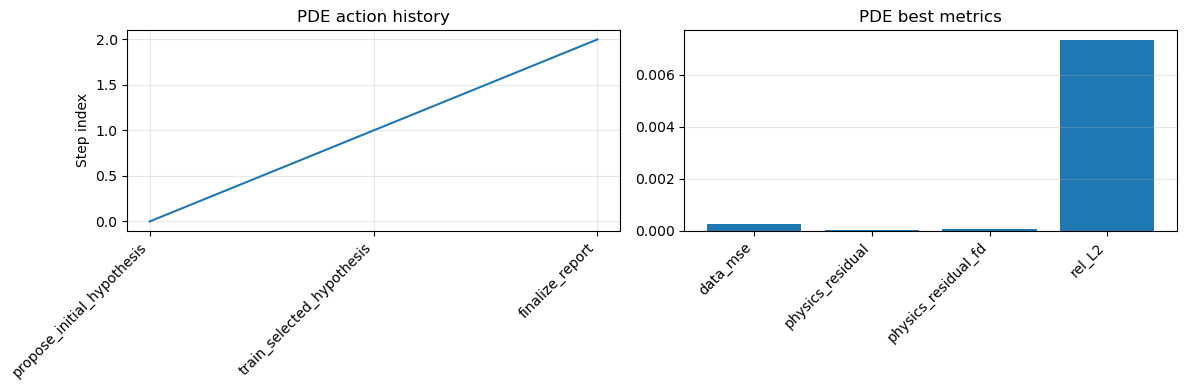


[PDE AGENT FINAL SUMMARY]
{
  "domain": "PDE",
  "step_idx": 3,
  "remaining_budget": 2,
  "done": true,
  "termination_reason": "Agent finalized report",
  "current_internal_hypothesis": "PDE_hyperbolic",
  "candidate_hypotheses": [
    "PDE_hyperbolic",
    "PDE_parabolic"
  ],
  "num_accepted": 1,
  "num_rejected": 0,
  "last_action": "finalize_report",
  "last_reason": "Agent finalized report",
  "best_metrics": {
    "data_mse": 0.00023482376127503812,
    "physics_residual": 3.214996831957251e-05,
    "rel_L2": 0.0073493425734341145,
    "physics_residual_fd": 6.374152872012928e-05
  },
  "belief": {
    "domain_belief": "PDE",
    "family_belief": "PDE_hyperbolic",
    "expert_belief": "SA_PINN",
    "progress_status": "good_enough",
    "main_bottleneck": "none",
    "exploration_mode": "exploit",
    "recommended_action": "finalize_report",
    "confidence": 0.95
  },
  "uncertainty": {
    "family_uncertainty": 0.2,
    "expert_uncertainty": 0.2,
    "stopping_uncertainty": 

In [17]:
# [Cell 17] — PDE experiment
# -----------------------------------------------------------------------------
# PURPOSE
# Run the agent on a Burgers-like PDE system.
# Use budget="fast" while debugging, then switch to "full".
# -----------------------------------------------------------------------------

Dp = _gen_pde_seed(nu_val=0.01, noise_std=0.0)
preview_pde_data(Dp)

pde_state = run_agent(
    "PDE",
    Dp,
    max_steps=5,
    budget="full",
    verbose=True,
)

print("\n" + "=" * 100)
print("[PDE AGENT FINAL SUMMARY]")
print_state(pde_state, verbose=True)

print("\n" + "=" * 100)
print("[PDE AGENT BELIEF]")
print_agent_belief(pde_state)

print("\n" + "=" * 100)
print("[PDE AGENT BEST RUN]")
print_agent_best(pde_state)

print("\n" + "=" * 100)
print("[PDE AGENT LATEST TOURNAMENT]")
print_latest_tournament_table(pde_state)

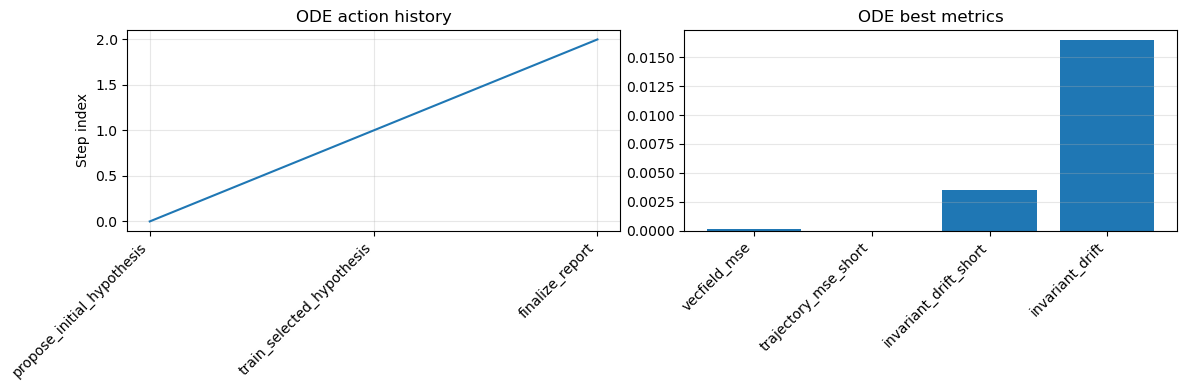


[ODE AGENT FINAL SUMMARY]
{
  "domain": "ODE",
  "step_idx": 3,
  "remaining_budget": 2,
  "done": true,
  "termination_reason": "Agent finalized report",
  "current_internal_hypothesis": "ODE_conservative",
  "candidate_hypotheses": [
    "ODE_conservative",
    "ODE_generic"
  ],
  "num_accepted": 1,
  "num_rejected": 0,
  "last_action": "finalize_report",
  "last_reason": "Agent finalized report",
  "best_metrics": {
    "vecfield_mse": 9.07541616470553e-05,
    "invariant_drift": 0.01651811403743311,
    "invariant_drift_short": 0.003543032187404889,
    "trajectory_mse_short": 1.636343085920089e-06,
    "h_magnitude": 9.000137329101562
  },
  "belief": {
    "domain_belief": "ODE",
    "family_belief": "ODE_conservative",
    "expert_belief": "HNN",
    "progress_status": "good_enough",
    "main_bottleneck": "none",
    "exploration_mode": "exploit",
    "recommended_action": "finalize_report",
    "confidence": 0.95
  },
  "uncertainty": {
    "family_uncertainty": 0.2,
    "ex

In [19]:
# [Cell 18] — ODE experiment
# -----------------------------------------------------------------------------
# PURPOSE
# Run the agent on a pendulum-like ODE system.
# -----------------------------------------------------------------------------

Do = _gen_ode_seed(noise_std=0.0)
preview_ode_data(Do)

ode_state = run_agent(
    "ODE",
    Do,
    max_steps=5,
    budget="fast",
    verbose=True,
)

print("\n" + "=" * 100)
print("[ODE AGENT FINAL SUMMARY]")
print_state(ode_state, verbose=True)

print("\n" + "=" * 100)
print("[ODE AGENT BELIEF]")
print_agent_belief(ode_state)

print("\n" + "=" * 100)
print("[ODE AGENT BEST RUN]")
print_agent_best(ode_state)

print("\n" + "=" * 100)
print("[ODE AGENT LATEST TOURNAMENT]")
print_latest_tournament_table(ode_state)

print("\n" + "=" * 100)
print_ode_specialists(ode_state)

print("\n" + "=" * 100)
print_ode_acceptance_summary(ode_state)

In [20]:
# [Cell 19] — Final reports
# -----------------------------------------------------------------------------
# PURPOSE
# Show domain-isolated reports directly in the notebook.
# -----------------------------------------------------------------------------

show_markdown_report("PDE Agent Report", getattr(pde_state, "final_report", None))
print("\n")
show_markdown_report("ODE Agent Report", getattr(ode_state, "final_report", None))

PDE Agent Report


# PDE Report

**Run ID:** AGENT-PDE-1775737669-4223  

**Accepted:** True — Accepted as baseline run

**PDE metrics:** data_mse=2.35e-04, physics_residual=3.21e-05, FD_residual=6.37e-05, rel_L2=7.35e-03

**Winner:** {"expert": "SA_PINN", "score": 4.0}

**Session:** {"num_runs": 1, "best": {"timestamp": "2026-04-09T12:27:49.140469Z", "run_id": "AGENT-PDE-1775737669-4223", "data_fp": "sha256:166436de63df88e2536a9839fe287d5b9963730a25fcd2deb1dc23100e565e51", "proposal": {"hypothesis_id": "pde.burgers", "params": {"nu_prior": [0.003, 0.03]}, "probes": {"t": [0.25, 0.5, 0.75], "x_windows": null}, "audits": ["fd_residual", "relL2@t=0.75"]}, "winner": {"expert": "SA_PINN", "score": 4.0}, "metrics": {"data_mse": 0.00023482376127503812, "physics_residual": 3.214996831957251e-05, "rel_L2": 0.0073493425734341145, "physics_residual_fd": 6.374152872012928e-05}, "audits": {"requested": ["fd_residual", "relL2@t=0.75"], "selected_hypothesis": "PDE_hyperbolic", "all_results": [{"expert": "SA_PINN", "score": 4.0, "scores": {"data_mse": 0.00023482376127503812, "physics_residual": 3.214996831957251e-05, "rel_L2": 0.0073493425734341145, "physics_residual_fd": 6.374152872012928e-05}}, {"expert": "FNO", "score": 1.0000000000000042, "scores": {"one_step_mse": 8.895682981346908e-07, "physics_residual_fd": 234.43228149414062}}], "ode_best_vecfield": null, "ode_best_conservative": null}, "accepted": true, "reason": "Accepted as baseline run"}}




ODE Agent Report


# ODE Report

**Run ID:** AGENT-ODE-1775738805-4239  

**Accepted:** True — Accepted as baseline run

**ODE metrics:** vecfield_mse=9.08e-05, traj_short=1.64e-06, drift_short=3.54e-03, drift_long=1.65e-02

**ODE satisfactory:** satisfactory=True (vf=9.08e-05, drift_short=3.54e-03, drift_long=1.65e-02)

**Winner:** {"expert": "HNN", "score": 3.0}

**Session:** {"num_runs": 1, "best": {"timestamp": "2026-04-09T12:46:45.764804Z", "run_id": "AGENT-ODE-1775738805-4239", "data_fp": "sha256:b239689ac43cdf83ffc94cc9c71fbe6e057e11ae4f1be366a0b85c8af920e7bb", "proposal": {"hypothesis_id": "ode.pendulum", "params": {"g_over_L_prior": [5.0, 12.0]}, "probes": {"t": [1.0, 2.0], "x_windows": null}, "audits": ["energy_drift", "vecfield_mse"]}, "winner": {"expert": "HNN", "score": 3.0}, "metrics": {"vecfield_mse": 9.07541616470553e-05, "invariant_drift": 0.01651811403743311, "invariant_drift_short": 0.003543032187404889, "trajectory_mse_short": 1.636343085920089e-06, "h_magnitude": 9.000137329101562}, "audits": {"requested": ["energy_drift", "vecfield_mse"], "selected_hypothesis": "ODE_conservative", "all_results": [{"expert": "HNN", "score": 3.0, "scores": {"vecfield_mse": 9.07541616470553e-05, "invariant_drift": 0.01651811403743311, "invariant_drift_short": 0.003543032187404889, "trajectory_mse_short": 1.636343085920089e-06, "h_magnitude": 9.000137329101562}}, {"expert": "LNN", "score": 1.0000000000130427, "scores": {"acc_mse": 1.206052303314209, "trajectory_mse_short": 0.0766737312078476}}], "ode_best_vecfield": {"expert": "HNN", "scores": {"vecfield_mse": 9.07541616470553e-05, "invariant_drift": 0.01651811403743311, "invariant_drift_short": 0.003543032187404889, "trajectory_mse_short": 1.636343085920089e-06, "h_magnitude": 9.000137329101562}, "score": 3.0}, "ode_best_conservative": {"expert": "HNN", "scores": {"vecfield_mse": 9.07541616470553e-05, "invariant_drift": 0.01651811403743311, "invariant_drift_short": 0.003543032187404889, "trajectory_mse_short": 1.636343085920089e-06, "h_magnitude": 9.000137329101562}, "score": 3.0}}, "accepted": true, "reason": "Accepted as baseline run"}}


In [21]:
# [Cell 20] — Raw session and evidence inspection
# -----------------------------------------------------------------------------
# PURPOSE
# Low-level inspection of domain-isolated sessions and evidence traces.
# -----------------------------------------------------------------------------

print("=" * 100)
print("[PDE SESSION SUMMARY]")
print("=" * 100)
print(json.dumps(pde_state.session.summary(), indent=2, default=str))

print("\n" + "=" * 100)
print("[PDE EVIDENCE TAIL]")
print("=" * 100)
print(json.dumps(pde_state.evidence.tail(5), indent=2, default=str))

print("\n" + "=" * 100)
print("[ODE SESSION SUMMARY]")
print("=" * 100)
print(json.dumps(ode_state.session.summary(), indent=2, default=str))

print("\n" + "=" * 100)
print("[ODE EVIDENCE TAIL]")
print("=" * 100)
print(json.dumps(ode_state.evidence.tail(5), indent=2, default=str))

[PDE SESSION SUMMARY]
{
  "num_runs": 1,
  "best": {
    "timestamp": "2026-04-09T12:27:49.140469Z",
    "run_id": "AGENT-PDE-1775737669-4223",
    "data_fp": "sha256:166436de63df88e2536a9839fe287d5b9963730a25fcd2deb1dc23100e565e51",
    "proposal": {
      "hypothesis_id": "pde.burgers",
      "params": {
        "nu_prior": [
          0.003,
          0.03
        ]
      },
      "probes": {
        "t": [
          0.25,
          0.5,
          0.75
        ],
        "x_windows": null
      },
      "audits": [
        "fd_residual",
        "relL2@t=0.75"
      ]
    },
    "winner": {
      "expert": "SA_PINN",
      "score": 4.0
    },
    "metrics": {
      "data_mse": 0.00023482376127503812,
      "physics_residual": 3.214996831957251e-05,
      "rel_L2": 0.0073493425734341145,
      "physics_residual_fd": 6.374152872012928e-05
    },
    "audits": {
      "requested": [
        "fd_residual",
        "relL2@t=0.75"
      ],
      "selected_hypothesis": "PDE_hyperbolic",
  